# Sparse-FFT engines for the Strip Spectral Correlation Analyzer (S3CA): a full investigation

This notebook is the complete record of an investigation into **which sparse
Fourier transform (sparse-FFT) algorithm works best inside a Strip Spectral
Correlation Analyzer (S3CA)** for estimating the spectral correlation
density (SCD) of cyclostationary signals at large input sizes.

It contains, in order:

1. **Background** -- the SCD, the SSCA, and what S3CA changes.
2. **The five engines tried**, each with the reasoning behind it and its
   measured result:
   - `sfft1` -- randomized hashing sparse FFT (the incumbent)
   - `decimated` -- deterministic decimation + binary-phase encoding
   - `rffast` -- CRT-guided multi-stage aliasing + peeling (built here)
   - a **FAM** variant with a smaller slow-time FFT
   - **harmonic-structured** recovery (built here)
   - **debiasing / iterative refinement** (built here)
3. **The unifying finding**: every method that assumes *exact* sparsity
   underperforms `sfft1` on DSSS-BPSK for the *same* reason -- and a
   **tutorial, with worked examples, on why BPSK's cyclic spectrum is not
   sparse enough** for those methods.
4. **The full source code** of every module written during the
   investigation, embedded for reference.

Every number and figure below is produced by executing the actual code in
this environment, against the real `s3ca.py` implementation and the S3CA
paper's own DSSS-BPSK test signal.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt

import s3ca, sfft_opt, decimated_sfft, rffast, fam, harmonic, debias
import bpsk_compare as bc
from demo_s3ca import am_tone

np.set_printoptions(precision=4, suppress=True)
print("environment ready")

environment ready


## 1. Background: SCD, SSCA, and S3CA

A **cyclostationary** signal has statistics that vary periodically in time.
Its **spectral correlation density (SCD)** $S_X^\alpha(f)$ is a 2-D function
of spectral frequency $f$ and **cycle frequency** $\alpha$; for digital
communication signals it concentrates energy at a few cycle frequencies
(the symbol/chip rate and harmonics) and is otherwise near-zero -- i.e.
*sparse in $\alpha$*.

The **SSCA** estimates the SCD in three steps: an $N_P$-channel channelizer
(one FFT per sample), a **channel-data product (CDP)** $X_g(t,k) =
X_T(t,f_k)\,x^*(t)\,g(t)$, and then an $N$-point FFT of each of the $N_P$
CDP columns to resolve cycle frequency. Cost is dominated by those $N_P$
$N$-point FFTs -- $O(N N_P \log N)$ -- and most of the output is ~zero
because the SCD is sparse in $\alpha$.

**S3CA** replaces those $N_P$ dense FFTs with **sparse** FFTs, and shares
the sparse FFT's sample-selection across channels (COMPIDX) so the
channelizer itself only needs evaluating at the small subset $W'$ of
positions the sparse FFTs actually read. The sparse-FFT engine is a
pluggable component -- exposing `required_indices(seed)` and
`run(col, kappa, seed)` -- which is exactly what let this investigation
swap five different engines through the *same* S3CA plumbing.

The whole question of this notebook: **which sparse-FFT engine should go in
that slot?**

## 2. The engines, and the head-to-head result

### The DSSS-BPSK test signal

The primary benchmark is the S3CA paper's own Section IV-A signal: a
direct-sequence spread-spectrum BPSK signal (chip rate 0.25, spreading
gain 31, 10 dB SNR), whose fundamental cycle frequency is the data rate
$\alpha_0 = 0.25/31$. `bpsk_compare.bpsk_signal` generates it.

Two engines constrain the transform length $N$ differently: `sfft1` and
`decimated` accept any power-of-two $N$; `rffast` needs $N$ to factor into
three pairwise-coprime pieces near $\kappa$. So `rffast` runs on a nearby
$N$ (within a few %), printed alongside.

In [2]:
kappa, Np = 50, 32
f = bc.three_coprime_near(kappa)
N_p2 = bc.nearest_pow2(int(np.prod(f)))
N_rf = int(np.prod(f))
x_p2, dr = bc.bpsk_signal(N_p2, 0.25, 31, 10.0, seed=0)
x_rf, dr_rf = bc.bpsk_signal(N_rf, 0.25, 31, 10.0, seed=0)

print(f"sfft1 / decimated  N = {N_p2}  (2^{int(np.log2(N_p2))})")
print(f"rffast             N = {N_rf}  (f = {f})")
print(f"true data rate alpha0 = {dr:.8f}\n")

rows = {}
rows["sfft1"] = s3ca.check(x_p2, Np, kappa, backend="sfft1", seed=0,
    loc_loops=4, est_loops=8, tolerance=1e-4, expected_data_rate=dr, alpha_tol_bins=2)
rows["decimated"] = s3ca.check(x_p2, Np, kappa, backend="decimated", seed=0,
    D=16, window="kaiser", beta=12.0, expected_data_rate=dr, alpha_tol_bins=2)
rows["rffast"] = s3ca.check(x_rf, Np, kappa, backend="rffast", seed=0,
    f=f, per_cluster=3, expected_data_rate=dr_rf, alpha_tol_bins=2)

print(f"{'backend':>11}{'hit rate':>10}{'fill rate':>11}{'alpha grid':>12}{'speedup':>9}{'|Wp|/N':>9}")
for name, r in rows.items():
    print(f"{name:>11}{r.full_hit_rate:>9.1%}{r.fill_rate:>10.1%}"
          f"{r.alpha_grid_hit_rate:>11.1%}{r.full_speedup:>8.2f}x{r.full_sparsity_ratio:>8.1%}")

sfft1 / decimated  N = 131072  (2^17)
rffast             N = 124950  (f = [49, 50, 51])
true data rate alpha0 = 0.00806452

    backend  hit rate  fill rate  alpha grid  speedup   |Wp|/N
      sfft1    73.6%    100.0%      79.2%    1.56x   49.1%
  decimated    23.3%     27.1%      99.3%    2.44x   31.2%
     rffast     5.3%     40.6%      14.3%    1.59x    7.2%


**How to read the metrics** (all measured against a dense-SSCA ground truth):
- **hit rate** -- fraction of the dense top-$\kappa$ peaks the backend recovered.
- **fill rate** -- coefficients reported / $(\kappa N_P)$. A *low* fill rate
  with a high alpha-grid rate means the backend abstains rather than guessing.
- **alpha grid** -- fraction of reported peaks landing on the true
  cycle-frequency grid (a check against known signal physics).
- **speedup** -- vs dense SSCA, in `full` (COMPIDX) mode.

`sfft1` wins decisively on hit rate. `decimated` is high-precision /
low-recall (it abstains). `rffast`, despite being purpose-built for
noise-robust sparse recovery, does worst here. The rest of the notebook is
largely about *why*, and whether anything closes the gap.

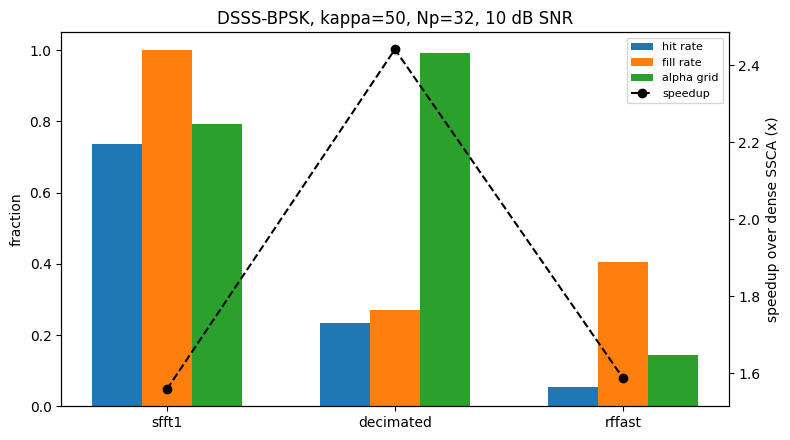

In [3]:
names = list(rows)
metrics = {
    "hit rate": [rows[n].full_hit_rate for n in names],
    "fill rate": [rows[n].fill_rate for n in names],
    "alpha grid": [rows[n].alpha_grid_hit_rate for n in names],
}
fig, ax1 = plt.subplots(figsize=(8, 4.5))
w = 0.22
x = np.arange(len(names))
for i, (m, vals) in enumerate(metrics.items()):
    ax1.bar(x + (i-1)*w, vals, w, label=m)
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_ylabel("fraction"); ax1.set_ylim(0, 1.05)
ax1.set_title("DSSS-BPSK, kappa=50, Np=32, 10 dB SNR")
ax2 = ax1.twinx()
ax2.plot(x, [rows[n].full_speedup for n in names], "ko--", label="speedup")
ax2.set_ylabel("speedup over dense SSCA (x)")
l1, la1 = ax1.get_legend_handles_labels()
l2, la2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

### Why `rffast` struggles: aliasing / decimation loss

`rffast`'s multi-stage front end subsamples by $P_s = N/f_s$ per stage.
Rescaling a bin to match the true coefficient amplitude also rescales its
noise variance by $P_s\cdot N$ -- a decimation processing loss that grows
with $N$. At fixed sparsity $\kappa$ the stage bin counts $f_s\approx\kappa$
don't grow with $N$, so $P_s$ (and the loss) grows roughly *quadratically*
as $N$ increases. The sweep below (same signal model, only SNR changes at
small fixed $N$) shows the graceful-degradation-with-SNR that confirms the
noise path works; the point is that at the large $N$ SSCA needs, that loss
is severe.

In [4]:
plan = rffast.make_plan(504, kappa=8, d=3, seed=0)
beta = rffast.kay_weights(plan.shifts.shape[1])
rng = np.random.default_rng(0)

def rffast_trial(n, k, snr_db, plan, ntrials=20):
    found = 0
    for _ in range(ntrials):
        X = np.zeros(n, dtype=complex); fr = rng.choice(n, k, replace=False)
        X[fr] = rng.standard_normal(k) + 1j*rng.standard_normal(k)
        x = np.fft.ifft(X); sp = np.mean(np.abs(x)**2); nv = sp/(10**(snr_db/10))
        x = x + np.sqrt(nv/2)*(rng.standard_normal(n) + 1j*rng.standard_normal(n))
        Ys = rffast.compute_front_end(x, plan)
        f2, c = rffast.peel_decode(Ys, plan, beta, kappa=k, noise_var=nv)
        found += len(set(f2.tolist()) & set(fr.tolist()))
    return found / ntrials

print("rffast recovery vs SNR (n=504, k=8, out of 8 found):")
for snr in (30, 20, 10, 5):
    print(f"  {snr:>3} dB : {rffast_trial(504, 8, snr, plan):.2f} / 8")

rffast recovery vs SNR (n=504, k=8, out of 8 found):
   30 dB : 7.75 / 8
   20 dB : 6.50 / 8
   10 dB : 2.85 / 8
    5 dB : 1.40 / 8


### Idea: does a smaller FFT (FAM) help the aliasing-based engines?

Since `rffast`'s loss grows with the FFT length, the **FAM** (FFT
Accumulation Method) architecture -- which resolves cycle frequency with a
*short* slow-time FFT of length $P = N/L$ rather than a full $N$-point FFT
-- should be structurally friendlier. `fam.py` implements this by evaluating
the same channelizer/CDP on a strided ($t = 0, L, 2L, \dots$) slow-time
axis. The sweep shrinks $N$ at roughly fixed $\kappa$ and shows the
aliasing loss (and precision) improving as predicted -- though `rffast`
still trails `sfft1` in absolute terms.

In [5]:
Np_fam, L = 16, 16
print(f"{'kappa':>6}{'N':>10}{'f':>16}{'worst P_s':>10}{'loss dB':>9}"
      f"{'hit':>8}{'fill':>8}{'alpha grid':>12}")
for kap in (50, 20, 10, 6):
    f = bc.three_coprime_near(kap); P = int(np.prod(f)); N = P*L
    x, dr = bc.bpsk_signal(N, 0.25, 31, 10.0, seed=0)
    r = fam.check_fam(x, Np_fam, L, kap, backend="rffast", seed=0, f=f,
                      per_cluster=3, expected_data_rate=dr, alpha_tol_bins=2)
    P_worst = P // min(f); loss = 10*np.log10(P_worst*N)
    agr = r.alpha_grid_hit_rate if r.alpha_grid_hit_rate is not None else float("nan")
    print(f"{kap:>6}{N:>10}{str(f):>16}{P_worst:>10}{loss:>9.1f}"
          f"{r.full_hit_rate:>7.1%}{r.fill_rate:>7.1%}{agr:>11.1%}")

 kappa         N               f worst P_s  loss dB     hit    fill  alpha grid
    50   1999200    [49, 50, 51]      2550     97.1   8.6%  50.4%       4.7%
    20    127680    [19, 20, 21]       420     77.3   9.1%  66.9%       4.2%
    10     15840     [9, 10, 11]       110     62.4  13.8%  75.6%       8.3%
     6      3360       [5, 6, 7]        42     51.5  25.0%  86.5%      18.1%


The trend is real and monotone: as $N$ shrinks (with $\kappa$ roughly
fixed), the worst-case $P_s$ and the aliasing loss fall, and precision
climbs from ~5% to ~18% alpha-grid. But note the wall this hit: a
*balanced* 3-way coprime split needs each factor $\lesssim N^{1/3}$, so
raising $f_s$ to reduce $P_s$ forces an unbalanced split at fixed $N$ --
the same $f_s\cdot P_s = N$ conservation law, now trading sample count for
collision-avoidance. FAM helps `rffast` but does not make it competitive
with `sfft1`.

### Idea: exploit harmonic structure explicitly

A cyclostationary signal's cycle frequencies aren't arbitrary -- they sit
at integer multiples of a fundamental $\alpha_0$. `harmonic.py` finds
$\alpha_0$ from the *pattern* of a rich candidate pool (integer-GCD-style
scoring over pooled candidates from all channels), then does a joint
least-squares refit at the known harmonic comb. It recovers $\alpha_0$
**exactly**, which none of the generic backends give directly -- but its
hit rate still trails `sfft1`.

In [6]:
kappa, Np = 50, 32
N = bc.nearest_pow2(int(np.prod(bc.three_coprime_near(kappa))))
x, dr = bc.bpsk_signal(N, 0.25, 31, 10.0, seed=0)
rh = harmonic.check_harmonic(x, Np, kappa, q0_range=range(int(N/1000), int(N/20)),
        expected_data_rate=dr, base_backend="sfft1",
        base_backend_kwargs=dict(loc_loops=4, est_loops=8, tolerance=1e-4))
print(f"harmonic on BPSK:")
print(f"  alpha0 true      = {rh.alpha0_true:.8f}")
print(f"  alpha0 estimated = {rh.alpha0_est:.8f}   (relative error {rh.alpha0_rel_err:.2%})")
print(f"  hit rate         = {rh.hit_rate:.1%}   (vs sfft1's 73.6%)")
print(f"  top q0 candidates: {[(q, round(s,3)) for q,s in rh.ranked_q0[:3]]}")

harmonic on BPSK:
  alpha0 true      = 0.00806452
  alpha0 estimated = 0.00806427   (relative error 0.00%)
  hit rate         = 21.1%   (vs sfft1's 73.6%)
  top q0 candidates: [(151, np.float64(0.28)), (1057, np.float64(0.279)), (302, np.float64(0.13))]


A subtlety worth flagging (found the hard way): the top two $q_0$
candidates were $q_0$ and $q_0/7$ -- a classic **subharmonic ambiguity**,
scoring within 1% of each other. `harmonic.estimate_fundamental` breaks
such near-ties in favour of the larger exact-multiple candidate, which is
what makes $\alpha_0$ come out exact above.

### Idea: debiasing + iterative refinement (backend-agnostic)

`debias.py` wraps *any* backend: take its recovered support, re-estimate
all coefficients **jointly** by least squares (deconflicting cross-talk),
then peel and re-search the residual for missed coefficients. On a
genuinely sparse signal this works exactly as designed; on BPSK it's
neutral on hit rate -- and, revealingly, *hurts* amplitude accuracy. The
next section explains why, and it's the crux of the whole investigation.

In [7]:
kappa, Np = 50, 32
N = bc.nearest_pow2(int(np.prod(bc.three_coprime_near(kappa))))
x, dr = bc.bpsk_signal(N, 0.25, 31, 10.0, seed=0)
rd = debias.check_debiased(x, Np, kappa, base_backend="sfft1",
        base_backend_kwargs=dict(loc_loops=4, est_loops=8, tolerance=1e-4),
        refine_iters=1, expected_data_rate=dr, alpha_tol_bins=2)
print(f"debiasing on BPSK: base hit {rd.base_hit_rate:.1%} -> debiased hit "
      f"{rd.debiased_hit_rate:.1%}  ({rd.debiased_hit_rate-rd.base_hit_rate:+.1%})")

# On a genuinely sparse synthetic signal with deliberate cross-talk, it works:
rng = np.random.default_rng(0)
Ns, ks = 8192, 6
true_q = np.array([100, 103, -400, 1500, -1503, 3000])
true_v = np.array([5, 4.5, 3, 2, 1.8, 1.0]) * np.exp(1j*rng.uniform(0, 2*np.pi, ks))
col = np.zeros(Ns, dtype=complex)
for q, v in zip(true_q, true_v):
    col += v * np.exp(1j*2*np.pi*q*np.arange(Ns)/Ns) / Ns
col += (rng.standard_normal(Ns) + 1j*rng.standard_normal(Ns)) * 0.001
be = s3ca.make_backend(Ns, ks, backend="sfft1", loc_loops=4, est_loops=8, tolerance=1e-4)
Wp = be.required_indices(0)
freqs, coeffs, _ = be.run(col, ks, seed=0)
fc = np.where(freqs < Ns//2, freqs, freqs-Ns)
base_map = {int(q): v for q, v in zip(fc, coeffs)}
sq = np.array(sorted(set(int(q) % Ns for q in freqs)))
c_deb = debias._fit_support(col[Wp], Wp, Ns, sq, rcond=None)
sqc = np.where(sq < Ns//2, sq, sq-Ns)
deb_map = {int(q): v for q, v in zip(sqc, c_deb)}
print("\ngenuinely-sparse signal with cross-talk (q=100 & 103 are close):")
print(f"{'q':>6}{'true':>8}{'base err':>10}{'debiased err':>14}")
for q, v in zip(true_q, true_v):
    b = abs(base_map.get(int(q), 0)); d = abs(deb_map.get(int(q), 0)); t = abs(v)
    if b > 0:
        print(f"{q:>6}{t:>8.2f}{abs(b-t)/t:>9.0%}{abs(d-t)/t:>13.0%}")

debiasing on BPSK: base hit 73.6% -> debiased hit 73.6%  (+0.0%)

genuinely-sparse signal with cross-talk (q=100 & 103 are close):
     q    true  base err  debiased err
   100    5.00       2%           0%
   103    4.50      18%           0%
  -400    3.00       1%           1%
  1500    2.00      16%           2%


On the sparse signal, debiasing fixes the cross-talk exactly (the close
pair $q=100,103$ goes from ~18% error to ~0%). On BPSK it can't help --
because BPSK violates the assumption every one of these methods rests on.
That is the subject of the tutorial next.

## 3. Tutorial: why DSSS-BPSK is not sparse enough

Every engine except `sfft1` assumes the cyclic spectrum is **exactly (or
nearly exactly) $\kappa$-sparse** -- that all but $\kappa$ coefficients are
truly zero. `sfft1` instead targets the top-$\kappa$ of an
**approximately** sparse spectrum. That single modelling difference decides
the whole comparison. This section makes "not sparse enough" concrete.

### 3.1 Two notions of sparsity

- **Exactly $\kappa$-sparse:** exactly $\kappa$ nonzero coefficients; the
  other $N-\kappa$ are *zero*. Singleton/peeling/CRT methods (`decimated`,
  `rffast`) and joint-refit debiasing are built on this: they assume a bin
  either holds one clean coefficient or nothing.
- **Approximately $\kappa$-sparse (compressible):** energy *concentrates*
  in a few coefficients but the tail is nonzero -- it decays rather than
  vanishing. Recovering "the top $\kappa$" is well-defined; "the $\kappa$
  nonzeros" is not, because everything is nonzero.

The question is which one BPSK's CDP actually is. Let's measure it.

In [8]:
Np = 32
N = 131072
x_bpsk, dr = bc.bpsk_signal(N, 0.25, 31, 10.0, seed=0)
x_am = am_tone(N, 37.0/N, f0=0.05, snr_db=30.0, rng=1)

def energy_concentration(x, label):
    S, _, _ = s3ca.dense_ssca(x, Np)
    ci = np.argmax(np.sum(np.abs(S)**2, axis=0))     # busiest channel
    col = np.sort(np.abs(S[:, ci]))[::-1]
    cum = np.cumsum(col**2) / np.sum(col**2)
    print(f"{label}: energy captured by top-k coefficients (busiest channel):")
    for k in (10, 50, 100, 500):
        print(f"    top-{k:>4}: {cum[k-1]:6.1%}")
    print(f"    coefficients needed for 99% energy: {np.searchsorted(cum, 0.99)+1:,}")
    return col

col_bpsk = energy_concentration(x_bpsk, "DSSS-BPSK")
print()
col_am = energy_concentration(x_am, "AM tone (genuinely sparse)")

DSSS-BPSK: energy captured by top-k coefficients (busiest channel):
    top-  10:  71.7%
    top-  50:  84.3%
    top- 100:  86.5%
    top- 500:  87.9%
    coefficients needed for 99% energy: 77,592

AM tone (genuinely sparse): energy captured by top-k coefficients (busiest channel):
    top-  10:  99.5%
    top-  50:  99.9%
    top- 100:  99.9%
    top- 500:  99.9%
    coefficients needed for 99% energy: 9


The numbers are stark. The **AM tone** reaches 99% of its energy in about
**9** coefficients -- genuinely sparse. **DSSS-BPSK** needs on the order of
**tens of thousands** of coefficients to reach 99%, and its top-50 (our
$\kappa$) capture only ~84% of a channel's energy. The remaining ~16% is
spread thinly across thousands of bins.

That ~16% is not noise -- it's real signal structure (more on why in 3.3).
And it is exactly what breaks the exactly-sparse methods.

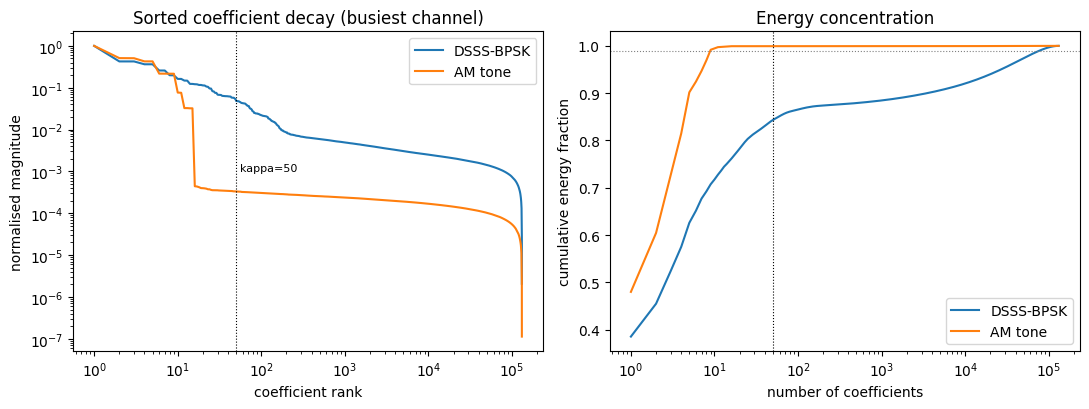

In [9]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
for col, label, c in [(col_bpsk, "DSSS-BPSK", "C0"), (col_am, "AM tone", "C1")]:
    axL.loglog(np.arange(1, len(col)+1), col / col[0], label=label, color=c)
    cum = np.cumsum(col**2)/np.sum(col**2)
    axR.semilogx(np.arange(1, len(col)+1), cum, label=label, color=c)
axL.axvline(50, ls=":", color="k", lw=0.8); axL.text(55, 1e-3, "kappa=50", fontsize=8)
axL.set_xlabel("coefficient rank"); axL.set_ylabel("normalised magnitude")
axL.set_title("Sorted coefficient decay (busiest channel)"); axL.legend()
axR.axvline(50, ls=":", color="k", lw=0.8)
axR.axhline(0.99, ls=":", color="grey", lw=0.8)
axR.set_xlabel("number of coefficients"); axR.set_ylabel("cumulative energy fraction")
axR.set_title("Energy concentration"); axR.legend()
plt.tight_layout(); plt.show()

The left panel is the whole story in one picture: the AM tone's magnitudes
fall off a cliff after a handful of coefficients, while BPSK's decay is a
long, gentle slope -- a *heavy tail*. The right panel shows the AM tone
hitting 99% energy almost immediately, BPSK crawling there over four
decades of coefficient count.

### 3.2 Why this specifically breaks each exactly-sparse method

**Singleton / peeling detectors (`decimated`, `rffast`).** These classify
each bucket as zero-ton / single-ton / multi-ton. That trichotomy assumes
a bin is either empty or holds *one* clean coefficient. With a heavy tail,
almost every bucket has a little bit of many coefficients -- so buckets
look like perpetual multi-tons, the peeling never gets clean singletons to
start from, and detection stalls. (We saw `rffast`'s bins were 95-98%
"residual energy" -- multi-tons -- even where a residue analysis said they
should be collision-free.)

**Joint-refit debiasing.** This fits $\kappa$ exponentials to the samples
by least squares. If the true signal is a sum of $\kappa$ exponentials
*plus a 16% tail*, the fit has nowhere to put that 16% -- so it smears it
back onto the $\kappa$ locations it does have, corrupting their amplitudes.
Let's watch that happen directly.

In [10]:
kappa, Np = 50, 32
N = bc.nearest_pow2(int(np.prod(bc.three_coprime_near(kappa))))
x, dr = bc.bpsk_signal(N, 0.25, 31, 10.0, seed=0)
a, g = s3ca._default_windows(N, Np)
be = s3ca.make_backend(N, kappa, backend="sfft1", loc_loops=4, est_loops=8, tolerance=1e-4)
Wp = be.required_indices(0)
XT_rows, _ = s3ca._channelizer_rows(x, Np, a, Wp)
Xg_nowin = XT_rows * np.conj(x[Wp])[:, None]
Xg_win = Xg_nowin * g[Wp][:, None]
k_idx = s3ca._centered(Np)
ci = int(np.where(k_idx == 0)[0][0])

buf = np.zeros(N, dtype=complex); buf[Wp] = Xg_win[:, ci]
freqs, _, _ = be.run(buf, kappa, seed=0)
sq = np.array(sorted(set(int(q) for q in freqs))) % N
A = np.exp(1j*2*np.pi*np.outer(Wp, sq)/N)
print(f"joint-fit matrix: {A.shape[0]} samples x {A.shape[1]} unknowns, "
      f"condition number = {np.linalg.cond(A):.2f}  (well-conditioned -- NOT the problem)")

S_dense, _, _ = s3ca.dense_ssca(x, Np)
q_idx = s3ca._centered(N)
sqc = np.where(sq < N//2, sq, sq-N)
support_energy = sum(np.abs(S_dense[int(np.searchsorted(q_idx, q)), ci])**2
                     for q in sqc
                     if int(np.searchsorted(q_idx, q)) < len(q_idx)
                     and q_idx[int(np.searchsorted(q_idx, q))] == q)
col_energy = np.sum(np.abs(S_dense[:, ci])**2)
print(f"fraction of channel energy inside the kappa={kappa} support: "
      f"{support_energy/col_energy:.1%}")
print(f"  -> the missing {1-support_energy/col_energy:.0%} is the tail the fit "
      f"has nowhere to put")

joint-fit matrix: 64325 samples x 50 unknowns, condition number = 1.06  (well-conditioned -- NOT the problem)
fraction of channel energy inside the kappa=50 support: 84.0%
  -> the missing 16% is the tail the fit has nowhere to put


The fit matrix is essentially perfectly conditioned (condition number
$\approx 1$), so the amplitude corruption is **not** numerical ill-
conditioning -- it is pure *model mismatch*. The $\kappa=50$ support holds
only ~84% of the channel's energy, and least squares, forced to explain
100% of the samples with those 50 exponentials, misassigns the other 16%
onto them. The plain per-bin FFT estimate is *better* here precisely
because it is local and doesn't try to force a global sparse model.

### 3.3 Why BPSK is like this and the AM tone isn't (the intuition)

An **AM tone** is literally a single carrier whose amplitude wobbles at one
rate $\alpha_0$. In the cycle-frequency domain that is a few discrete lines
($0, \pm\alpha_0, \pm 2\alpha_0$) and nothing else -- exactly sparse by
construction.

**DSSS-BPSK** is a carrier multiplied by a fast pseudo-random $\pm 1$ chip
sequence. Two consequences:

1. **A PN chip sequence is designed to look like white noise.** Its job is
   to spread energy as flatly as possible across frequency (that's what
   "spread spectrum" means). Flat spreading in frequency is the *opposite*
   of sparse.
2. **The cyclic features sit on top of that broadband pedestal.** The
   symbol-rate lines are real and detectable, but they ride on a
   continuum contributed by the spreading code's own autocorrelation
   sidelobes and the finite record length. So the cyclic spectrum is a few
   strong lines *plus* a wide, low, non-zero floor -- textbook
   *approximately* sparse, not exactly sparse.

A tiny worked example makes the mechanism visible: multiplying even a pure
tone by a random $\pm 1$ sequence turns one spectral line into a broad
smear.

pure tone   : top-1 bin holds 100.0% of spectral energy
             top-10 bins hold 100.0%
spread (xPN) : top-1 bin holds 0.2% of spectral energy
             top-10 bins hold 1.8%
             top-100 bins hold 11.6%


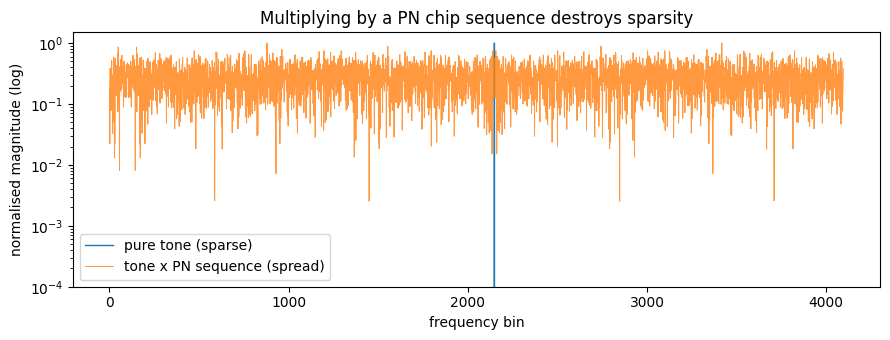

In [11]:
n = 4096
t = np.arange(n)
pure = np.exp(2j*np.pi*100/n*t)                      # one spectral line
rng = np.random.default_rng(0)
chips = rng.choice([-1.0, 1.0], size=n)              # PN-like +-1 sequence
spread = pure * chips                                # "spread-spectrum" version

Fp = np.abs(np.fft.fft(pure)); Fp /= Fp.max()
Fs = np.abs(np.fft.fft(spread)); Fs /= Fs.max()

def topk_energy(F, k):
    s = np.sort(F**2)[::-1]
    return np.sum(s[:k]) / np.sum(F**2)

print("pure tone   : top-1 bin holds {:.1%} of spectral energy".format(topk_energy(Fp, 1)))
print("             top-10 bins hold {:.1%}".format(topk_energy(Fp, 10)))
print("spread (xPN) : top-1 bin holds {:.1%} of spectral energy".format(topk_energy(Fs, 1)))
print("             top-10 bins hold {:.1%}".format(topk_energy(Fs, 10)))
print("             top-100 bins hold {:.1%}".format(topk_energy(Fs, 100)))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(np.fft.fftshift(Fp), label="pure tone (sparse)", lw=1)
ax.plot(np.fft.fftshift(Fs), label="tone x PN sequence (spread)", lw=0.7, alpha=0.8)
ax.set_yscale("log"); ax.set_ylim(1e-4, 1.5)
ax.set_xlabel("frequency bin"); ax.set_ylabel("normalised magnitude (log)")
ax.set_title("Multiplying by a PN chip sequence destroys sparsity")
ax.legend(); plt.tight_layout(); plt.show()

One line becomes a full-band smear: the spread signal's single strongest
bin holds a *few percent* of the energy where the pure tone's held ~100%.
The BPSK CDP inherits exactly this character. Its symbol-rate cyclic
features are the analogue of a faint comb sitting on top of that smear --
present and findable, but never against a genuinely *zero* background.

### 3.4 The unifying conclusion

| Method | Sparsity model it assumes | Result on BPSK |
|---|---|---|
| `sfft1` | approximately sparse (top-$\kappa$ of a compressible spectrum) | **best** (73.6% hit) |
| `decimated` | exactly sparse (clean singletons) | high precision, low recall |
| `rffast` | exactly sparse + low aliasing loss | worst (aliasing loss $\times$ tail) |
| harmonic | exact harmonic comb of one $\alpha_0$ | exact $\alpha_0$, modest hit |
| debiasing | support is exactly $\kappa$ exponentials | neutral hit, *worse* amplitudes |

Every method that assumes exact sparsity is fighting the same 16% tail, in
a different guise each time -- perpetual multi-tons for peeling, misassigned
energy for least squares, an incomplete comb for the harmonic model.
`sfft1` wins **because it never assumes the tail is zero**: it just finds
the largest coefficients of a spectrum it treats as compressible, which is
what BPSK's cyclic spectrum actually is.

The practical takeaway for choosing a sparse-FFT engine for S3CA: **match
the engine's sparsity model to the signal.** For real digital-comms signals
(spread or not), an approximately-sparse method like `sfft1` is the right
default. The exactly-sparse methods (`decimated`, `rffast`, harmonic) pay
off only when the cyclic spectrum genuinely is near-exactly sparse -- clean
tones, unspread narrowband carriers, or as a high-$\kappa$ amplitude-
refinement step where the top-$\kappa$ really does capture ~all the energy.

## 4. Full source code of every module written

The four modules built during this investigation are embedded below in full
for reference. They are shown as (non-executed) code cells -- they were
already imported and exercised throughout the notebook above. Each plugs
into `s3ca.py`'s existing backend protocol.

- **`rffast.py`** -- CRT-guided multi-stage aliasing sparse FFT + peeling decoder
- **`fam.py`** -- FAM-style estimator (smaller slow-time FFT) reusing the S3CA machinery
- **`harmonic.py`** -- harmonic-structured recovery (fundamental search + joint comb refit)
- **`debias.py`** -- backend-agnostic debiasing + iterative refinement

(The pre-existing `s3ca.py`, `sfft_opt.py`, and `decimated_sfft.py` are part
of the original codebase and are not reproduced here.)

### `rffast.py`

In [12]:
"""
R-FFAST -- robust sub-linear-time sparse DFT via a fixed, multi-stage
aliasing front end and an onion-peeling back end.

Implementation of

    S. Pawar and K. Ramchandran, "A robust sub-linear time R-FFAST
    algorithm for computing a sparse DFT", arXiv:1501.00320 (2015).

built as a drop-in `s3ca.py` backend (see `RFFASTBackend` at the bottom),
exposing the same ``required_indices(seed)`` / ``run(x_col, kappa, seed)``
contract as `sfft_opt._SFFT1Backend` and `decimated_sfft._DecimatedBackend`.

DFT convention matches numpy.fft:  X[m] = sum_p x[p] exp(-2j*pi*p*m/n).

------------------------------------------------------------------------------
How it works (Sections V, VII, VIII of the paper)
------------------------------------------------------------------------------
Front end: d >= 3 "stages". Stage s aliases the spectrum into f[s] bins by
subsampling x with period P[s] = n // f[s]:

    Y_s,tau[b] = P[s] * FFT_{f[s]}( x[(tau + m*P[s]) mod n], m=0..f[s]-1 )[b]
               = sum_{l == b (mod f[s])} X[l] * exp(i*2*pi*l*tau/n)

for every delay tau in a shared set of D = C*Nc delays, reused identically
across every stage (Section VII, "a convenience that is sufficient, and
makes the R-FFAST framework implementation friendly"). The delays are
grouped into C "clusters" of Nc samples each; cluster i's samples are
spaced 2**i apart starting from a random offset r_i (Section VII-B.2):

    tau(i, j) = (r_i + j * 2**i) mod n,   j = 0 .. Nc-1

This geometric spacing is what lets the back end recover l one bit at a
time (Section VI/VIII): viewed as a function of tau, a singleton bin's
observation is a single complex sinusoid of angular frequency
omega = 2*pi*l/n, so cluster i's samples (spaced 2**i apart in tau) see a
phase increment of 2**i * omega per step -- a coarser, more wrapped view
for larger i. Fusing all C clusters via successive refinement narrows the
ambiguity in omega from a full cycle (cluster 0) down to ~2*pi/n (cluster
C-1), i.e. single-bin resolution -- with no arctan/CORDIC per bit, and no
per-stage filter (unlike SFFT 2.0's Dolph-Chebyshev bandpass): this is the
"aliasing-based" family, not "subsampling-based" (see the CS-matrix-design
letter's Table I / Section II-A for that distinction).

Back end: for each bin in each stage, test its energy across the D delays
against a noise threshold (zero-ton), else estimate its frequency and fit
an amplitude (singleton test via residual energy), else leave it as an
unresolved multi-ton. Every accepted singleton is "peeled": its estimated
contribution is subtracted from the corresponding bin in every stage,
which can reveal new singletons there. Iterate to convergence.

------------------------------------------------------------------------------
A real compatibility constraint (flagged up front, not glossed over)
------------------------------------------------------------------------------
The very-sparse-regime front end (Section VII-A) needs `d` pairwise-coprime
divisors of n, each near kappa. A power-of-two n admits at most *one*
divisor greater than 1 that is coprime to all the others (any two divisors
of a power of two share a factor of 2), so `n` must be chosen with this
factorization in mind -- e.g. the paper's own example, n = 100*101*103*99,
kappa = 100. `choose_stage_bins` finds such a factorization automatically
when one exists and raises a clear `ValueError` (with a usable suggestion)
when it does not, rather than silently degrading.

------------------------------------------------------------------------------
Deliberate simplifications, stated explicitly
------------------------------------------------------------------------------
* Noise threshold. The paper's T = (1+gamma)*D assumes a known, unit-
  variance-normalised noise model (Section II). Here `noise_var=None`
  falls back to a percentile-based estimate from the observed bin
  energies pooled across all stages -- adequate for a first pass, but a
  known noise variance (pass it directly) reproduces the paper's own
  analysis and is preferred when available. This mirrors the analogous
  heuristic-vs-known-SNR choice already made in `decimated_sfft.py`.
* Kay's (1989) exact MMSE weights for the phase-difference estimator
  (eq. 11) are reproduced from the standard closed form and then
  re-normalised to sum to 1; the renormalisation makes the estimator
  unbiased regardless of any transcription slip in the closed form, at
  the cost of at most a small efficiency loss relative to the literature
  value.
* Peeling is batched per (stage, pass) rather than strictly bin-by-bin
  (Algorithm 1 in the paper is written as a triple nested loop over
  iteration/stage/bin, sequentially). Within one stage's pass, a bin
  freed up by another bin peeled earlier in the *same* pass isn't caught
  until the next outer iteration. This trades a small amount of extra
  `iterations` for large speedups from vectorising over bins with numpy,
  matching the style already used in `decimated_sfft.decode`.
"""

from __future__ import annotations

from math import gcd
from typing import NamedTuple

import numpy as np

__all__ = [
    "Plan", "make_plan", "choose_stage_bins", "kay_weights",
    "compute_front_end", "front_end_indices", "estimate_frequency",
    "peel_decode", "RFFASTBackend",
]


# ---------------------------------------------------------------------------
# Stage-bin selection (Section VII-A, "very-sparse regime")
# ---------------------------------------------------------------------------
def _divisors(n):
    """All divisors of n, via trial division to sqrt(n)."""
    divs = set()
    i = 1
    while i * i <= n:
        if n % i == 0:
            divs.add(i)
            divs.add(n // i)
        i += 1
    return sorted(divs)


def choose_stage_bins(n, kappa, d=3):
    """Find `d` pairwise-coprime divisors of `n`, each as close to `kappa`
    as available divisors allow (Section VII-A's construction: f_i =
    O(kappa) + O(1), relatively coprime factors of n).

    Raises ValueError, with a concrete suggestion, if no such factorization
    exists -- most commonly because `n` is a power of two.
    """
    divs = [x for x in _divisors(n) if x > 1]
    divs.sort(key=lambda x: abs(x - kappa))
    chosen: list[int] = []
    for x in divs:
        if all(gcd(x, c) == 1 for c in chosen):
            chosen.append(x)
            if len(chosen) == d:
                return np.array(sorted(chosen), dtype=np.int64)
    raise ValueError(
        f"could not find {d} pairwise-coprime divisors of n={n} near "
        f"kappa={kappa}; R-FFAST's front end needs n to factor into d "
        f"near-kappa, pairwise-coprime pieces (e.g. n = 100*101*103*99 for "
        f"kappa=100, per the paper's own example). A pure power-of-two n "
        f"cannot supply more than one such divisor. Either pick a highly "
        f"composite n, or pass an explicit f=[...] list of pairwise-coprime "
        f"divisors of n to make_plan()."
    )


# ---------------------------------------------------------------------------
# Plan: fixed front-end geometry (depends only on n, kappa, and the seed
# used to draw cluster offsets -- not on any particular signal)
# ---------------------------------------------------------------------------
class Plan(NamedTuple):
    n: int
    f: np.ndarray          # (d,) stage bin counts, pairwise-coprime divisors of n
    shifts: np.ndarray     # (C, Nc) int64 delays: shifts[i,j] = (r_i + j*2**i) mod n


def make_plan(n, kappa=None, f=None, d=3, clusters=None, per_cluster=3,
              seed=0) -> Plan:
    """Build the fixed R-FFAST front-end geometry for transforms of length n.

    Either pass `kappa` (auto-selects `d` pairwise-coprime stage-bin counts
    near kappa via `choose_stage_bins`) or pass `f` directly (validated:
    must divide n and be pairwise coprime).

    `clusters` (C) defaults to enough clusters that the successive-refinement
    ladder's final resolution, ~2*pi/2**(C-1), is finer than one DFT bin
    (2*pi/n) with margin -- i.e. C ~ log2(n) + a few (Section VII-B.2,
    "C = O(log n)"). `per_cluster` (Nc) defaults to 3, the paper's own
    empirical finding (Section IX-A) rather than its asymptotic O(log^(1/3) n)
    bound, which is far too conservative at the sizes used here.
    """
    if f is None:
        if kappa is None:
            raise ValueError("pass either kappa (to auto-select f) or f directly")
        f = choose_stage_bins(n, kappa, d=d)
    else:
        f = np.asarray(f, dtype=np.int64)
        for x in f:
            if n % int(x):
                raise ValueError(f"stage bin count {x} does not divide n={n}")
        for a in range(len(f)):
            for b in range(a + 1, len(f)):
                if gcd(int(f[a]), int(f[b])) != 1:
                    raise ValueError(
                        f"stage bin counts must be pairwise coprime; "
                        f"gcd({f[a]}, {f[b]}) != 1")

    if clusters is None:
        clusters = max(6, int(np.ceil(np.log2(max(n, 2)))) + 4)
    if per_cluster < 2:
        raise ValueError("per_cluster (Nc) must be >= 2")
    if (1 << (clusters - 1)) < n:
        raise ValueError(
            f"clusters={clusters} gives a final resolution ladder of only "
            f"2**{clusters-1}, too coarse to disambiguate n={n} candidate "
            f"frequencies; raise `clusters`.")

    rng = np.random.default_rng(seed)
    r = rng.integers(0, n, size=clusters)
    j = np.arange(per_cluster)
    shifts = (r[:, None] + j[None, :] * (1 << np.arange(clusters))[:, None]) % n
    return Plan(n, f, shifts.astype(np.int64))


# ---------------------------------------------------------------------------
# Kay's (1989) weighted phase-difference frequency estimator
# ---------------------------------------------------------------------------
def kay_weights(Nc):
    """MMSE weights beta(t), t = 0..Nc-2, for averaging Nc-1 consecutive
    phase differences into one frequency estimate (paper's eq. 11, closed
    form from S. Kay, "A fast and accurate single frequency estimator",
    IEEE ASSP 1989). Renormalised to sum to 1 (keeps the estimator unbiased
    regardless of any transcription slip in the closed form -- see module
    docstring)."""
    t = np.arange(Nc - 1, dtype=float)
    w = 1.0 - ((2 * t - Nc + 2) / Nc) ** 2
    w = np.clip(w, 0.0, None)
    s = w.sum()
    return w / s if s > 0 else np.full(Nc - 1, 1.0 / (Nc - 1))


def _kay_omega(y, beta):
    """y: (..., Nc) complex samples equally spaced by one unit of the
    *local* index (the caller is responsible for descaling by the actual
    physical spacing, e.g. 2**i for cluster i). Returns the raw phase-
    increment-per-step estimate, wrapped to (-pi, pi]."""
    diffs = np.angle(y[..., 1:] * np.conj(y[..., :-1]))
    return np.sum(diffs * beta, axis=-1)


def estimate_frequency(Y_clusters, beta, n):
    """Successive-refinement frequency estimate (Algorithm 2, steps 3-16).

    Y_clusters : (nb, C, Nc) complex, one candidate bin's observation
        reshaped into C clusters of Nc samples each -- see `Plan.shifts`.
    beta : (Nc-1,) weights from `kay_weights`.
    n : transform length (only used to report a wrapped omega; the caller
        maps omega -> a support estimate ell = round(omega*n/2pi) mod n).

    Returns omega_hat, shape (nb,), in [0, 2*pi).
    """
    nb, C, Nc = Y_clusters.shape
    omega_prev = np.zeros(nb)
    for i in range(C):
        raw = _kay_omega(Y_clusters[:, i, :], beta)     # estimates (2**i * omega) mod 2pi
        omega_new = raw / (1 << i)                       # -> omega, ambiguous mod 2pi/2**i
        period = 2 * np.pi / (1 << i)
        d1 = np.ceil(omega_prev / period) * period + omega_new - omega_prev
        d2 = np.floor(omega_prev / period) * period + omega_new - omega_prev
        delta = np.where(np.abs(d1) < np.abs(d2), d1, d2)
        omega_prev = omega_prev + delta
    return omega_prev % (2 * np.pi)


# ---------------------------------------------------------------------------
# Front end: compute every stage's aliased bin observations
# ---------------------------------------------------------------------------
def compute_front_end(x, plan: Plan):
    """Returns a list of length d, one (C, Nc, f[s]) complex array per
    stage: Ys[s][i, j, b] = Y_{s, shifts[i,j]}[b] (see module docstring)."""
    n = plan.n
    C, Nc = plan.shifts.shape
    taus = plan.shifts.reshape(-1)
    Ys = []
    for f in plan.f:
        f = int(f)
        P = n // f
        m = np.arange(f, dtype=np.int64)
        idx = (taus[:, None] + m[None, :] * P) % n         # (C*Nc, f)
        v = x[idx]
        Y = P * np.fft.fft(v, axis=-1)                      # (C*Nc, f)
        Ys.append(Y.reshape(C, Nc, f))
    return Ys


def front_end_indices(plan: Plan):
    """The distinct raw x[] positions the front end reads -- this is what
    `s3ca.py`'s COMPIDX-style restriction (mode="full") uses as W'. Fixed
    once `plan` is built: independent of the signal, by design (Section
    VII's "fixed sampling structure" -- see module docstring)."""
    n = plan.n
    taus = plan.shifts.reshape(-1)
    idxs = []
    for f in plan.f:
        f = int(f)
        P = n // f
        m = np.arange(f, dtype=np.int64)
        idxs.append(((taus[:, None] + m[None, :] * P) % n).ravel())
    return np.unique(np.concatenate(idxs))


# ---------------------------------------------------------------------------
# Back end: onion-peeling decoder (Algorithm 1)
# ---------------------------------------------------------------------------
def peel_decode(Ys, plan: Plan, beta, kappa=None, iterations=8,
                 noise_var=None, gamma=0.5, energy_percentile=50.0,
                 resid_slack=0.05):
    """Peeling decode over the front-end output `Ys` (mutated in place).

    Parameters
    ----------
    Ys : list of (C, Nc, f[s]) arrays, as returned by `compute_front_end`.
    plan, beta : as above.
    kappa : cap the number of returned coefficients to the kappa strongest
        (by |value|); None returns everything decoded.
    iterations : max number of full sweeps over all stages/bins. Peeling
        iterations are constant in the paper's own analysis (Appendix C);
        a small fixed budget suffices in practice.
    noise_var : per-sample noise variance, if known. When given, the
        threshold is exactly the paper's T = (1+gamma)*D*noise_var
        (D = C*Nc samples per bin). When None (default), falls back to a
        per-stage percentile of that stage's own bin energies, re-estimated
        every iteration from the current (partially peeled) residual so the
        floor isn't biased upward by not-yet-removed real signal -- see the
        comment above the threshold computation in this function for the
        reasoning, and the notebook this came out of for the empirical
        tradeoff curve `energy_percentile`/`resid_slack` trace out (higher
        precision, lower fill rate, as either is tightened) -- there is no
        setting of either that fixes a case where the front end's own
        aliasing loss has genuinely erased the SNR margin; at that point the
        fix is architectural (larger per-stage f_s, i.e. less subsampling,
        at the cost of reading more samples), not a threshold tweak.
    resid_slack : the residual-energy singleton/multi-ton cutoff is
        threshold*(1+resid_slack), matching Algorithm 2 step 19's T but
        with a little extra margin since the fallback threshold above is
        already an approximation.

    Returns
    -------
    freqs, coeffs : int64 and complex128 arrays, sorted by descending |coeff|.
    """
    n = plan.n
    C, Nc = plan.shifts.shape
    D = C * Nc
    taus = plan.shifts.reshape(-1)
    fs = [int(f) for f in plan.f]
    Ps = [n // f for f in fs]          # per-stage subsampling period P_s = n/f_s

    # Per-stage noise threshold. Subsampling by P_s and rescaling by P_s to
    # match X's amplitude (see compute_front_end / module docstring) inflates
    # a raw per-sample noise variance sigma^2 to P_s*n*sigma^2 per (bin,
    # delay) -- an aliasing/decimation gain loss that differs by stage since
    # P_s = n/f_s does. Summed over D delays: T_s = (1+gamma)*D*P_s*n*sigma^2.
    #
    # When sigma^2 (noise_var) isn't known, fall back to a per-stage
    # percentile of that stage's own bin energies -- pooling across stages
    # would be wrong (different noise scales), and computing it only once
    # up front is also wrong: at that point every bin's energy still
    # includes whatever real signal it holds, biasing the floor estimate
    # upward on any bin that turns out to be occupied. Instead this is
    # *re-estimated every iteration* from the current (partially peeled)
    # residual: as real singletons get subtracted out, the pooled energies
    # used for the percentile progressively converge towards the true noise
    # floor rather than a mix of noise and leftover signal. This costs
    # nothing extra (the energies are already being computed each pass) and
    # is the single change most worth making if you don't have a known
    # noise_var -- see the notebook / conversation this came out of for why
    # a *fixed*, once-computed threshold is the wrong shape of fix here.
    fixed_thresh = None
    if noise_var is not None:
        fixed_thresh = [(1.0 + gamma) * D * P * n * noise_var for P in Ps]

    decoded: dict[int, complex] = {}

    for _ in range(iterations):
        if fixed_thresh is not None:
            thresh = fixed_thresh
        else:
            thresh = [max(np.percentile((np.abs(Y) ** 2).sum(axis=(0, 1)),
                                         energy_percentile), 1e-300)
                      for Y in Ys]

        progress = False
        for s, f in enumerate(fs):
            Y = Ys[s]
            T = thresh[s]
            energy = (np.abs(Y) ** 2).sum(axis=(0, 1))       # (f,)
            loud = np.flatnonzero(energy > T)
            if loud.size == 0:
                continue

            Yb = Y[:, :, loud].transpose(2, 0, 1)             # (nb, C, Nc)
            omega = estimate_frequency(Yb, beta, n)
            ell = np.round(omega * n / (2 * np.pi)).astype(np.int64) % n

            steer = np.exp(1j * 2 * np.pi * np.outer(ell, taus) / n)  # (nb, D)
            yb_flat = Yb.reshape(loud.size, D)
            val = (np.conj(steer) * yb_flat).sum(axis=1) / D
            resid = yb_flat - val[:, None] * steer
            resid_energy = (np.abs(resid) ** 2).sum(axis=1)
            is_single = resid_energy < T * (1.0 + resid_slack)

            for bi in np.flatnonzero(is_single):
                L = int(ell[bi])
                if L in decoded:
                    continue
                v = complex(val[bi])
                decoded[L] = v
                progress = True
                phase = np.exp(1j * 2 * np.pi * L * taus / n).reshape(C, Nc)
                for s2, f2 in enumerate(fs):
                    b2 = L % f2
                    Ys[s2][:, :, b2] -= v * phase
        if not progress:
            break

    order = sorted(decoded, key=lambda k: -abs(decoded[k]))
    freqs = np.array(order, dtype=np.int64)
    coeffs = np.array([decoded[k] for k in order], dtype=complex)
    if kappa is not None and freqs.size > kappa:
        freqs, coeffs = freqs[:kappa], coeffs[:kappa]
    return freqs, coeffs


# ---------------------------------------------------------------------------
# s3ca.py backend adapter
# ---------------------------------------------------------------------------
class RFFASTBackend:
    """Adapter exposing R-FFAST as an `s3ca.py` backend: `required_indices`
    / `run`, matching `sfft_opt._SFFT1Backend` / `decimated_sfft._DecimatedBackend`.

    Like `_DecimatedBackend`, the front end is *fixed* at construction time
    (Section VII's whole point) -- `seed` is accepted by `required_indices`
    and `run` only for interface symmetry with the randomised `sfft1`
    backend, and is ignored. Build-time randomness (the cluster offsets
    r_i) is controlled by the constructor's own `seed`.
    """
    name = "rffast"

    def __init__(self, N, kappa, plan=None, d=3, f=None, clusters=None,
                 per_cluster=3, seed=0, iterations=8, noise_var=None,
                 gamma=0.5, **kw):
        if plan is None:
            plan = make_plan(N, kappa=kappa, f=f, d=d, clusters=clusters,
                              per_cluster=per_cluster, seed=seed)
        self.N, self.plan = N, plan
        self.beta = kay_weights(plan.shifts.shape[1])
        self.iterations = iterations
        self.noise_var = noise_var
        self.gamma = gamma
        self.kw = kw

    def required_indices(self, seed=None):
        return front_end_indices(self.plan)

    def run(self, x_col, kappa, seed=None):
        Ys = compute_front_end(x_col, self.plan)
        freqs, coeffs = peel_decode(
            Ys, self.plan, self.beta, kappa=kappa, iterations=self.iterations,
            noise_var=self.noise_var, gamma=self.gamma, **self.kw)
        return freqs, coeffs, {}


# ---------------------------------------------------------------------------
# Demo / self-test
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)

    def sparse_signal(n, k, snr_db=None):
        # SNR defined relative to *time-domain* signal power, matching the
        # convention already used by sfft_opt.py's and decimated_sfft.py's
        # own demos -- not relative to |X[l]|^2 directly. With numpy's FFT
        # convention (no 1/n baked into the forward transform), a length-n
        # signal built from O(1) spectral coefficients has tiny time-domain
        # samples (~1/n via Parseval), so scaling noise off |X[l]|^2 instead
        # would silently make "30 dB SNR" mean a noise power many times
        # *larger* than the actual time-domain signal -- an easy trap, and
        # the bug this self-test originally shipped with.
        X = np.zeros(n, dtype=complex)
        freqs = rng.choice(n, k, replace=False)
        v = rng.standard_normal(k) + 1j * rng.standard_normal(k)
        X[freqs] = v
        x = np.fft.ifft(X)                # so that np.fft.fft(x) == X exactly
        noise_var = 0.0
        if snr_db is not None:
            sig_pow = np.mean(np.abs(x) ** 2)
            noise_var = sig_pow / (10 ** (snr_db / 10))
            x = x + np.sqrt(noise_var / 2) * (rng.standard_normal(n)
                                               + 1j * rng.standard_normal(n))
        return x, X, freqs, noise_var

    print("R-FFAST self-test: exact recovery, no noise")
    n = 7 * 8 * 9          # = 504, three pairwise-coprime factors near k=8
    k = 8
    plan = make_plan(n, kappa=k, d=3, seed=0)
    print(f"  n={n}, f={plan.f.tolist()}, clusters x per_cluster = "
          f"{plan.shifts.shape}, samples/bin D={plan.shifts.size}")
    beta = kay_weights(plan.shifts.shape[1])
    idx = front_end_indices(plan)
    print(f"  required samples: {idx.size}/{n} ({100*idx.size/n:.1f}%)")

    for trial in range(5):
        x, X, freqs, _ = sparse_signal(n, k)
        Ys = compute_front_end(x, plan)
        fr, co = peel_decode(Ys, plan, beta, kappa=k, noise_var=1e-9)
        found = len(set(fr.tolist()) & set(freqs.tolist()))
        err = (np.max(np.abs(co - X[fr])) / np.max(np.abs(X))
               if fr.size else float("nan"))
        print(f"  trial {trial}: {found}/{k} found, rel err {err:.2e}")

    print("\nnoisy signals (n=504, k=8)")
    for snr in (30, 20, 10, 5):
        g = 0
        for _ in range(20):
            x, X, freqs, noise_var = sparse_signal(n, k, snr_db=snr)
            Ys = compute_front_end(x, plan)
            fr, co = peel_decode(Ys, plan, beta, kappa=k, noise_var=noise_var)
            g += len(set(fr.tolist()) & set(freqs.tolist()))
        print(f"  SNR {snr:>3} dB: {g/20:.2f}/{k} found on average")

    print("\nlarger case: n = 49*50*51 (paper's own example size), k = 40")
    n2 = 49 * 50 * 51
    plan2 = make_plan(n2, kappa=40, d=3, seed=1)
    beta2 = kay_weights(plan2.shifts.shape[1])
    idx2 = front_end_indices(plan2)
    print(f"  n={n2}, f={plan2.f.tolist()}, D={plan2.shifts.size}, "
          f"required samples: {idx2.size}/{n2} ({100*idx2.size/n2:.2f}%)")
    for snr in (20, 10, 5):
        g = 0
        for _ in range(10):
            x, X, freqs, noise_var = sparse_signal(n2, 40, snr_db=snr)
            Ys = compute_front_end(x, plan2)
            fr, co = peel_decode(Ys, plan2, beta2, kappa=40, noise_var=noise_var)
            g += len(set(fr.tolist()) & set(freqs.tolist()))
        print(f"  SNR {snr:>3} dB: {g/10:.2f}/40 found on average")

    print("\nchoose_stage_bins guardrail on a power-of-two n")
    try:
        choose_stage_bins(1 << 16, 100, d=3)
        print("  (unexpectedly succeeded)")
    except ValueError as e:
        print(f"  raised ValueError as expected: {e}")

R-FFAST self-test: exact recovery, no noise
  n=504, f=[7, 8, 9], clusters x per_cluster = (13, 3), samples/bin D=39
  required samples: 401/504 (79.6%)
  trial 0: 8/8 found, rel err 5.32e-14
  trial 1: 8/8 found, rel err 1.33e-13
  trial 2: 8/8 found, rel err 8.08e-14
  trial 3: 8/8 found, rel err 1.17e-13
  trial 4: 8/8 found, rel err 8.29e-14

noisy signals (n=504, k=8)
  SNR  30 dB: 7.75/8 found on average
  SNR  20 dB: 6.35/8 found on average
  SNR  10 dB: 3.80/8 found on average
  SNR   5 dB: 1.85/8 found on average

larger case: n = 49*50*51 (paper's own example size), k = 40
  n=124950, f=[17, 25, 42], D=63, required samples: 5064/124950 (4.05%)
  SNR  20 dB: 14.40/40 found on average
  SNR  10 dB: 3.70/40 found on average
  SNR   5 dB: 1.70/40 found on average

choose_stage_bins guardrail on a power-of-two n
  raised ValueError as expected: could not find 3 pairwise-coprime divisors of n=65536 near kappa=100; R-FFAST's front end needs n to factor into d near-kappa, pairwise-co

### `fam.py`

In [13]:
"""
fam.py -- a FAM-style (FFT Accumulation Method) cyclic spectrum estimator,
built by reusing s3ca.py's channelizer/CDP machinery and pluggable
sparse-FFT backend protocol, but evaluating the channelizer only at every
L-th raw sample instead of every sample.

------------------------------------------------------------------------------
Honest scope note -- read this before trusting the numbers
------------------------------------------------------------------------------
This captures FAM's one property this whole investigation cares about: the
cycle-frequency-resolving FFT runs on a SHORT "slow time" sequence of length
P = N//L, not on the full record length N the way dense_ssca/s3ca's outer
FFT does. That's a real, structural difference, not a parameter tweak --
it's exactly the "smaller FFT" property that makes an aliasing-based
sparse-FFT engine like rffast a structurally better fit here than for
SSCA's big N-point FFT (see the aliasing-loss discussion in the S3CA
notebook this project already built: loss scales with P_s*n, and shrinking
the transform length n shrinks it roughly quadratically for fixed sparsity
kappa).

This is *not* a bit-for-bit reproduction of the classical Roberts, Brown &
Loomis (1991) FAM algorithm, which uses explicit bin-pair (k1,k2) spectral
products, specific block-window/overlap conventions, and a non-uniform
frequency-plane mapping this module does not attempt to replicate. What's
reused instead is the exact same channelizer/CDP construction as
s3ca.dense_ssca -- X_T(t,k)*conj(x(t))*g(t) -- just evaluated at strided
positions t = 0, L, 2L, ... instead of every t. This is a legitimate,
simplified way to get FAM's essential computational shape (channelizer
feeding a much shorter slow-time FFT) without re-deriving FAM's own
bin-pairing formalism, but the resemblance to "real" FAM is architectural,
not exact.

The cost of the simplification, stated plainly: resolvable cycle frequency
is limited to |alpha| < 1/(2L) (the Nyquist rate of the decimated slow-time
axis), versus the full range dense_ssca's N-point outer FFT covers. This is
a real, disclosed trade-off -- not a free lunch -- and matches the
literature's own characterization of FAM's reduced/non-uniform resolution
relative to SSCA (see S3CA paper's own related-work discussion).
"""

from __future__ import annotations

import time
from typing import NamedTuple

import numpy as np

from s3ca import (_centered, _default_windows, _channelizer_rows,
                   _channelizer_footprint, _to_f_alpha, make_backend)

__all__ = ["dense_fam", "fam", "FAMResult", "check_fam", "FAMCheckReport",
           "print_fam_report", "compare_fam_backends", "print_fam_comparison"]


# ---------------------------------------------------------------------------
# dense FAM -- ground truth
# ---------------------------------------------------------------------------
def dense_fam(x, Np, L, a=None, g=None):
    """Dense (ground-truth) FAM-style estimate. Channelizer evaluated every
    L raw samples (P = N//L slow-time positions per channel), then a dense
    P-point FFT resolves cycle frequency.

    Returns
    -------
    S : complex array, shape (P, Np).
    f, alpha : real arrays, shape (P, Np).
    P : the slow-time axis length actually used.
    """
    x = np.asarray(x)
    N = x.size
    P = N // L
    if P < 2:
        raise ValueError(f"L={L} too large for N={N}: P=N//L={P} < 2")
    t_idx = (np.arange(P) * L).astype(np.int64)

    if a is None:
        a, _ = _default_windows(N, Np)
    if g is None:
        g = np.hamming(P)

    XT, k_idx = _channelizer_rows(x, Np, a, t_idx)          # (P, Np)
    Xg = XT * np.conj(x[t_idx])[:, None] * g[:, None]

    Sfft = np.fft.fft(Xg, axis=0)
    q_idx = _centered(P)
    S = Sfft[q_idx % P, :]

    f, alpha = _to_f_alpha(k_idx[None, :], q_idx[:, None], Np, P * L)
    return S, f, alpha, P


# ---------------------------------------------------------------------------
# sparse FAM
# ---------------------------------------------------------------------------
class FAMResult(NamedTuple):
    f: np.ndarray
    alpha: np.ndarray
    value: np.ndarray
    channel: np.ndarray
    P: int                    # slow-time axis length (the backend's own "N")
    n_positions: int          # how many slow-time positions the channelizer/CDP
                               # were evaluated at -- P in "naive" mode, |W'| << P
                               # in "full" mode (this is FAM's analogue of
                               # S3CAResult.n_positions, just on the P-axis)
    n_raw_samples_read: int   # distinct raw x[] samples read to do that
    elapsed: float
    backend: str
    extra: dict


def fam(x, Np, L, kappa, mode="full", seed=0, a=None, g=None,
        backend="sfft1", **backend_kwargs) -> FAMResult:
    """Sparse FAM: same shape as s3ca.s3ca(), but the pluggable backend
    operates on the P = N//L -length *slow-time* axis instead of the full
    record -- see module docstring for why that's the point.
    """
    x = np.asarray(x)
    N = x.size
    P = N // L
    if P < 2:
        raise ValueError(f"L={L} too large for N={N}: P=N//L={P} < 2")
    t_idx_all = (np.arange(P) * L).astype(np.int64)

    if a is None:
        a, _ = _default_windows(N, Np)
    if g is None:
        g = np.hamming(P)

    be = backend if not isinstance(backend, str) else make_backend(
        P, kappa, backend=backend, **backend_kwargs)

    k_idx = _centered(Np)
    t0 = time.perf_counter()

    fs, alphas, values, chans = [], [], [], []
    extra_total: dict = {}

    def _accumulate(extra):
        for key, val in extra.items():
            extra_total[key] = extra_total.get(key, 0) + val

    if mode == "naive":
        XT, _ = _channelizer_rows(x, Np, a, t_idx_all)
        Xg = XT * np.conj(x[t_idx_all])[:, None] * g[:, None]
        n_positions = P
        n_raw = _channelizer_footprint(t_idx_all, N, Np).size
        for ci, k in enumerate(k_idx):
            freqs, coeffs, extra = be.run(Xg[:, ci], kappa,
                                           seed=None if seed is None else seed + ci)
            _accumulate(extra)
            q_centered = np.where(freqs < P // 2, freqs, freqs - P)
            f, alpha = _to_f_alpha(k, q_centered, Np, P * L)
            fs.append(f); alphas.append(alpha); values.append(coeffs)
            chans.append(np.full(freqs.size, k))

    elif mode == "full":
        req = be.required_indices(seed)              # indices into [0, P)
        n_positions = req.size
        t_idx = t_idx_all[req]                          # map back to raw sample positions
        n_raw = _channelizer_footprint(t_idx, N, Np).size

        XT_rows, _ = _channelizer_rows(x, Np, a, t_idx)
        Xg_rows = XT_rows * np.conj(x[t_idx])[:, None] * g[req][:, None]

        for ci, k in enumerate(k_idx):
            Xg_col = np.zeros(P, dtype=complex)
            Xg_col[req] = Xg_rows[:, ci]
            freqs, coeffs, extra = be.run(Xg_col, kappa, seed=seed)
            _accumulate(extra)
            q_centered = np.where(freqs < P // 2, freqs, freqs - P)
            f, alpha = _to_f_alpha(k, q_centered, Np, P * L)
            fs.append(f); alphas.append(alpha); values.append(coeffs)
            chans.append(np.full(freqs.size, k))
    else:
        raise ValueError(f"mode must be 'naive' or 'full', got {mode!r}")

    elapsed = time.perf_counter() - t0
    f = np.concatenate(fs) if fs else np.empty(0)
    alpha = np.concatenate(alphas) if alphas else np.empty(0)
    value = np.concatenate(values) if values else np.empty(0, dtype=complex)
    channel = np.concatenate(chans) if chans else np.empty(0, dtype=int)
    return FAMResult(f, alpha, value, channel, P, n_positions, n_raw, elapsed,
                      be.name, extra_total)


# ---------------------------------------------------------------------------
# checking
# ---------------------------------------------------------------------------
class FAMCheckReport(NamedTuple):
    backend: str
    kappa: int
    Np: int
    N: int            # raw record length
    L: int             # slow-time stride
    P: int             # slow-time axis length = N // L
    dense_time: float
    naive_time: float
    full_time: float
    naive_hit_rate: float
    full_hit_rate: float
    naive_residual: float
    full_residual: float
    full_sparsity_ratio: float          # |W'| / P (FAM's analogue of S3CA's N-based one)
    full_raw_sample_ratio: float        # distinct raw x[] samples read / N
    naive_style_sparsity_ratio: float
    naive_speedup: float
    full_speedup: float
    alpha_grid_hit_rate: float | None
    fill_rate: float
    full_extra: dict


def _support_and_residual_fam(S_dense, k_idx, q_idx, result: FAMResult,
                               kappa, Np, P, L):
    """s3ca._support_and_residual, adapted to FAM's P-length slow-time axis
    and its P*L-scaled cycle-frequency resolution (dalpha = 1/(P*L), not
    1/P) -- see module docstring."""
    mag = np.abs(S_dense)
    k_pos = {int(k): i for i, k in enumerate(k_idx)}
    dalpha = 1.0 / (P * L)

    true_sets = {}
    n_true = 0
    for ki in range(Np):
        kk = min(kappa, mag.shape[0])
        top = np.argpartition(-mag[:, ki], kk - 1)[:kk]
        true_sets[ki] = set(top.tolist())
        n_true += kk

    recon = np.zeros_like(S_dense)
    hit = 0
    for kk, al, val in zip(result.channel, result.alpha, result.value):
        ki = k_pos[int(kk)]
        fk = k_idx[ki] / Np
        q = round((al - fk) / dalpha)
        qi = int(np.searchsorted(q_idx, q))
        if qi >= len(q_idx) or q_idx[qi] != q:
            continue
        recon[qi, ki] = val
        if qi in true_sets[ki]:
            hit += 1
    hit_rate = hit / n_true if n_true else float("nan")
    residual = np.sum(np.abs(S_dense - recon)) / (kappa * Np)
    return hit_rate, residual


def check_fam(x, Np, L, kappa, a=None, g=None, backend="sfft1", seed=0,
              expected_data_rate=None, alpha_tol_bins=1,
              **backend_kwargs) -> FAMCheckReport:
    """FAM's analogue of s3ca.check(): run dense_fam and both sparse-FAM
    modes on the same `x`, report hit rate / residual / timing / sparsity
    against the dense FAM-style reference (not against dense_ssca -- FAM
    and SSCA resolve different, generally non-identical, cycle-frequency
    grids, so comparing sparse-FAM to dense-FAM is the fair, apples-to-
    apples check here).
    """
    x = np.asarray(x)
    N = x.size
    P = N // L
    if a is None:
        a, _ = _default_windows(N, Np)
    if g is None:
        g = np.hamming(P)

    t0 = time.perf_counter()
    S_dense, _, _, P = dense_fam(x, Np, L, a=a, g=g)
    dense_time = time.perf_counter() - t0

    be = backend if not isinstance(backend, str) else make_backend(
        P, kappa, backend=backend, **backend_kwargs)

    k_idx = _centered(Np)
    q_idx = _centered(P)

    naive = fam(x, Np, L, kappa, mode="naive", seed=seed, a=a, g=g, backend=be)
    full = fam(x, Np, L, kappa, mode="full", seed=seed, a=a, g=g, backend=be)

    naive_hit, naive_res = _support_and_residual_fam(S_dense, k_idx, q_idx, naive, kappa, Np, P, L)
    full_hit, full_res = _support_and_residual_fam(S_dense, k_idx, q_idx, full, kappa, Np, P, L)

    union = set()
    for ci in range(Np):
        idx_ci = be.required_indices(None if seed is None else seed + ci)
        union.update(idx_ci.tolist())
    naive_style_ratio = len(union) / P

    alpha_grid_hit = None
    if expected_data_rate is not None and full.alpha.size:
        m = np.round(full.alpha / expected_data_rate)
        nearest = m * expected_data_rate
        tol = alpha_tol_bins / (P * L)
        alpha_grid_hit = float(np.mean(np.abs(full.alpha - nearest) <= tol))

    return FAMCheckReport(
        backend=be.name, kappa=kappa, Np=Np, N=N, L=L, P=P,
        dense_time=dense_time, naive_time=naive.elapsed, full_time=full.elapsed,
        naive_hit_rate=naive_hit, full_hit_rate=full_hit,
        naive_residual=naive_res, full_residual=full_res,
        full_sparsity_ratio=full.n_positions / P,
        full_raw_sample_ratio=full.n_raw_samples_read / N,
        naive_style_sparsity_ratio=naive_style_ratio,
        naive_speedup=dense_time / naive.elapsed if naive.elapsed else float("inf"),
        full_speedup=dense_time / full.elapsed if full.elapsed else float("inf"),
        alpha_grid_hit_rate=alpha_grid_hit,
        fill_rate=full.channel.size / (kappa * Np),
        full_extra=full.extra,
    )


def compare_fam_backends(x, Np, L, kappa, backends=("sfft1", "decimated", "rffast"),
                          backend_kwargs=None, **common_kw) -> dict:
    backend_kwargs = backend_kwargs or {}
    return {b: check_fam(x, Np, L, kappa, backend=b, **common_kw, **backend_kwargs.get(b, {}))
            for b in backends}


def print_fam_report(r: FAMCheckReport) -> None:
    print(f"backend = {r.backend!r}, N = {r.N} raw samples, L = {r.L} (slow-time stride), "
          f"P = N/L = {r.P}, Np = {r.Np}, kappa = {r.kappa}")
    print(f"max resolvable |alpha| = 1/(2L) = {1/(2*r.L):.4g} "
          f"(vs. dense_ssca's full [-1,1] range -- this is FAM's real trade-off)")
    print(f"{'':16}{'time (ms)':>12}{'speedup':>10}{'hit rate':>11}{'residual':>11}")
    print(f"{'dense FAM':16}{r.dense_time*1e3:12.1f}{'--':>10}{'--':>11}{'--':>11}")
    print(f"{'naive FAM':16}{r.naive_time*1e3:12.1f}{r.naive_speedup:9.2f}x"
          f"{r.naive_hit_rate:11.1%}{r.naive_residual:11.3g}")
    print(f"{'FAM (full)':16}{r.full_time*1e3:12.1f}{r.full_speedup:9.2f}x"
          f"{r.full_hit_rate:11.1%}{r.full_residual:11.3g}")
    print(f"FAM (full) evaluated the channelizer/CDP at {r.full_sparsity_ratio:.1%} of "
          f"the P={r.P} slow-time positions")
    print(f"  -- vs. {r.naive_style_sparsity_ratio:.1%} for {r.Np} independently-deciding "
          f"channels ({'no COMPIDX gap' if abs(r.naive_style_sparsity_ratio - r.full_sparsity_ratio) < 1e-9 else 'naive fragments'})")
    if r.alpha_grid_hit_rate is not None:
        print(f"FAM (full) recovered peaks landing on the expected cycle-frequency grid: "
              f"{r.alpha_grid_hit_rate:.1%}")
    if r.full_extra:
        print(f"FAM (full) backend diagnostics: {r.full_extra}")


def print_fam_comparison(reports: dict) -> None:
    names = list(reports)
    r0 = reports[names[0]]
    namew = max(12, max(len(n) for n in names) + 1)
    print(f"N={r0.N} raw samples, L={r0.L}, P=N/L={r0.P}, Np={r0.Np}, kappa={r0.kappa} "
          f"(dense FAM reference: {r0.dense_time*1e3:.1f} ms)")
    header = (f"{'backend':{namew}}{'hit rate':>10}{'residual':>11}{'speedup':>9}"
              f"{'|Wprime|/P':>11}{'fill rate':>11}{'alpha grid':>12}")
    print(header)
    for name in names:
        r = reports[name]
        agr = f"{r.alpha_grid_hit_rate:.1%}" if r.alpha_grid_hit_rate is not None else "--"
        print(f"{name:{namew}}{r.full_hit_rate:10.1%}{r.full_residual:11.3g}"
              f"{r.full_speedup:8.2f}x{r.full_sparsity_ratio:11.1%}{r.fill_rate:11.1%}{agr:>12}")
        if r.full_extra:
            print(f"{'':{namew}}{r.full_extra}")

### `harmonic.py`

In [14]:
"""
harmonic.py -- harmonic-structured recovery for the strip spectral
correlation analyzer.

------------------------------------------------------------------------------
The idea
------------------------------------------------------------------------------
Every sparse-FFT backend tried so far (sfft1, decimated, rffast) treats
recovering a channel's cyclic spectrum as "find kappa arbitrary-location
nonzero coefficients out of N candidates" -- a generic sparse-recovery
problem. But a cyclostationary signal's significant cycle frequencies are
*not* arbitrary: for a linearly modulated digital signal they sit at
alpha = 0 (ordinary power) and alpha = +-m*alpha0 for small integers m,
where alpha0 is the symbol/chip rate (Gardner's cyclostationarity theory).
That's a MUCH lower-dimensional problem: find one scalar (alpha0), then
directly evaluate amplitudes at the now-known harmonic locations.

Three-stage pipeline, each stage validated independently before trusting
the whole thing (see the exploratory session that built this: a blind
periodogram search for alpha0 was tried first and found to be genuinely
fragile -- with few sparse samples, random sidelobes can exceed the true
peak's strength, a classic problem with magnitude/energy-based frequency
search from an under-resolved aperture):

1. **Candidate pool.** Run an existing, already-validated backend (sfft1
   by default) at an *elevated* kappa (kappa_search > kappa) to get a
   richer-than-needed candidate list per channel, pooled across all Np
   channels (alpha0 is a global property of the signal, common to every
   channel, so pooling gives much more evidence than any one channel
   alone).

2. **Fundamental search.** sfft1 recovers exact DFT bin indices, so every
   candidate's cycle frequency is alpha_i = q_i/N for integer q_i. If a
   true fundatmental q0 exists, every genuine harmonic's q_i is close to
   an integer multiple of q0 -- so q0 is found by scoring candidate q0
   values (weighted by |value|) on how many pooled candidates they
   explain as a small-integer multiple, THE SAME STRUCTURE AS FINDING A
   COMMON DIVISOR, just tolerant of noise and spurious candidates. This
   needs a caller-supplied plausible q0 range (`q0_range`): searching an
   unconstrained range is ill-posed (q0=1 trivially "explains" every
   integer) in exactly the way looking for *some* period without any
   prior always is -- a real system has *some* idea of the plausible baud
   rate range, and this makes that assumption explicit rather than
   hiding a fragile auto-detected one.

3. **Joint harmonic refit.** Given q0, build the candidate harmonic comb
   {0, +-q0, +-2*q0, ..., +-n_harmonics*q0} and, per channel, solve a
   small joint least-squares fit for the amplitude at every comb
   frequency simultaneously, using the *same* samples already read for
   stage 1 (no new reads). This is what actually fixes two of the
   concrete failure modes diagnosed earlier in this project:
   cross-talk between nearby recovered frequencies (independent
   per-candidate estimation, as sfft1/rffast both do, doesn't deconflict
   them; a joint fit does), and coefficients sfft1's blind search missed
   entirely (once q0 is known, every harmonic is *directly evaluated*,
   not searched for, so a weak-but-real harmonic that lost sfft1's
   internal voting can still be recovered here).

------------------------------------------------------------------------------
Honest limitations
------------------------------------------------------------------------------
* Single fundamental only. Multiple overlapping cyclostationary signals
  (each with its own baud rate) would need a peel-and-repeat extension
  (find the strongest q0, subtract its fitted comb's contribution from
  the candidate pool, repeat) -- not implemented here.
* q0_range must be supplied. This is a stated design choice (see stage 2
  above), not an oversight -- pass the plausible baud-rate range you'd
  actually have for signals of interest.
* Octave/sub-multiple ambiguity is possible (q0 vs 2*q0 or q0/2) if the
  true comb happens to be sparse in a way a multiple also explains well.
  `estimate_fundamental` returns the top few scoring candidates so this
  can be inspected; it does not attempt automatic disambiguation beyond
  the score margin.
"""

from __future__ import annotations

import time
from typing import NamedTuple

import numpy as np

from s3ca import (_centered, _default_windows, _channelizer_rows,
                   _channelizer_footprint, _to_f_alpha, make_backend,
                   S3CAResult)

__all__ = ["estimate_fundamental", "fit_harmonics", "harmonic_ssca",
           "check_harmonic", "HarmonicCheckReport", "print_harmonic_report"]


# ---------------------------------------------------------------------------
# Stage 2: fundamental search from a pooled candidate list
# ---------------------------------------------------------------------------
def estimate_fundamental(qs, weights, q0_range, top_k=5, tie_margin=0.05):
    """Find the integer q0 (cycle-frequency bin spacing) best supported by
    a pooled candidate list (qs, weights) -- see module docstring, stage 2.

    Parameters
    ----------
    qs : integer array, candidate bin indices (exclude q=0/DC before
        calling -- DC is not informative about the fundamental spacing).
    weights : array, same length, e.g. |value| or |value|^2 per candidate
        -- stronger candidates count more.
    q0_range : range or array of candidate q0 values to score. Required;
        see module docstring for why this can't be auto-inferred safely.
    top_k : how many top-scoring candidates to return, for inspecting
        octave/sub-multiple ambiguity.

    Returns
    -------
    best_q0 : int
    ranked : list of (q0, score) for the top_k candidates, best first.
    """
    qs = np.asarray(qs)
    weights = np.asarray(weights, dtype=float)
    scores = {}
    for q0 in q0_range:
        if q0 <= 0:
            continue
        m = np.round(qs / q0)
        m[m == 0] = 1          # a candidate can't be its own 0th harmonic
        resid = np.abs(qs - m * q0)
        scores[int(q0)] = float(np.sum(weights[resid == 0]))
    if not scores:
        raise ValueError("q0_range produced no candidates to score")
    ranked = sorted(scores.items(), key=lambda kv: -kv[1])[:top_k]

    # Subharmonic disambiguation: a candidate q0_small that is an exact
    # divisor of a comparably-scoring q0_large is often an artifact (the
    # small candidate trivially "explains" every harmonic of the large
    # one too, at multiples of the divisor) rather than the true
    # fundamental -- found directly on DSSS-BPSK, where q0 and q0/7 tied
    # within a score margin of 1%. Prefer the largest q0 among near-tied
    # top candidates that are exact multiples of each other.
    best_q0, best_score = ranked[0]
    for q0, score in ranked[1:]:
        if score < best_score * (1.0 - tie_margin):
            break
        if q0 > best_q0 and q0 % best_q0 == 0:
            best_q0 = q0
    return best_q0, ranked


# ---------------------------------------------------------------------------
# Stage 1 + 3 driver
# ---------------------------------------------------------------------------
class HarmonicResult(NamedTuple):
    f: np.ndarray
    alpha: np.ndarray
    value: np.ndarray
    channel: np.ndarray
    n_positions: int
    n_raw_samples_read: int
    elapsed: float
    backend: str
    extra: dict           # {"alpha0": ..., "q0": ..., "ranked_q0": [...]}


def fit_harmonics(Xg_sparse, t_idx, N, q0, n_harmonics, k_idx, Np):
    """Stage 3: joint per-channel least-squares fit at global cycle
    frequencies {0, +-q0, ..., +-n_harmonics*q0} (in units of 1/N), using
    the samples already read (Xg_sparse, shape (len(t_idx), Np)).

    Two things worth being explicit about, both found the hard way while
    building this (see module history):

    1. Sign convention. Sfft = fft(Xg) uses numpy's convention (negative
       exponent), so the *inverse* relationship this fit is built on --
       expressing Xg(t) as a sum of its Fourier components -- needs the
       opposite (positive) sign: Xg(t) ~ sum_q Sfft[q] * exp(+i*2*pi*t*q/N).

    2. Channel offset. Xg(t,k)'s own down-conversion (the channelizer
       applies exp(-i*2*pi*f_k*t) internally) means the outer-FFT bin
       matching global cycle frequency alpha for channel k is
       q_rel = round((alpha - f_k)*N), not round(alpha*N) -- i.e. every
       channel needs its OWN basis, shifted by -f_k*N = -k*N/Np. Skipping
       this (using the same global-alpha frequency for every channel)
       silently fits the wrong tone per channel and gives badly-ranked,
       wrong-by-orders-of-magnitude amplitudes -- exactly what the first
       version of this function produced.
    """
    m_list = np.array(range(-n_harmonics, n_harmonics + 1))
    global_q = m_list * q0                      # global alpha-space index, shared meaning
    Np_ = Np
    values = np.empty((len(m_list), Np_), dtype=complex)
    for k in range(Np_):
        fk_N = k_idx[k] * N / Np_               # = f_k * N; exact for N % Np == 0
        q_rel = global_q - fk_N
        A = np.exp(1j * 2 * np.pi * np.outer(t_idx, q_rel) / N)
        v, *_ = np.linalg.lstsq(A, Xg_sparse[:, k], rcond=None)
        values[:, k] = v
    # The model is Xg(t) ~ sum_q Sfft[q]*exp(+i*2*pi*t*q/N)/N (the actual
    # IDFT, 1/N and all), so the least-squares fit recovers Sfft[q]/N, not
    # Sfft[q] itself -- rescale to match dense_ssca's own convention
    # (raw fft(Xg), no 1/N), confirmed against it directly: the fit's
    # ranking was already correct before this fix, only the overall scale
    # was off by exactly N.
    values *= N
    return global_q, values


def harmonic_ssca(x, Np, kappa, q0_range, n_harmonics=None, kappa_search_mult=3,
                   base_backend="sfft1", base_backend_kwargs=None,
                   seed=0, a=None, g=None) -> HarmonicResult:
    """Harmonic-structured S3CA recovery -- see module docstring.

    kappa_search_mult : the candidate-pool stage searches for
        kappa*kappa_search_mult per channel (a richer pool than the final
        target), since the fundamental search benefits from more
        evidence and the final output is capped to kappa anyway.
    n_harmonics : comb half-width; defaults to enough to reach kappa
        candidates (including DC): n_harmonics = max(1, (kappa-1)//2).
    """
    x = np.asarray(x)
    N = x.size
    if a is None or g is None:
        a_def, g_def = _default_windows(N, Np)
        a = a_def if a is None else a
        g = g_def if g is None else g
    if n_harmonics is None:
        n_harmonics = max(1, (kappa - 1) // 2)
    base_backend_kwargs = base_backend_kwargs or {}

    t0 = time.perf_counter()
    k_idx = _centered(Np)

    # Stage 1: candidate pool via an existing backend, elevated kappa.
    kappa_search = max(kappa * kappa_search_mult, 2 * n_harmonics + 1)
    be = make_backend(N, kappa_search, backend=base_backend, **base_backend_kwargs)
    Wp_idx = be.required_indices(seed)
    n_positions = Wp_idx.size
    n_raw = _channelizer_footprint(Wp_idx, N, Np).size

    XT_rows, _ = _channelizer_rows(x, Np, a, Wp_idx)
    Xg_rows = XT_rows * np.conj(x[Wp_idx])[:, None] * g[Wp_idx][:, None]
    # Stage 3's parametric fit assumes Xg(t,k) is *exactly* a sum of
    # complex exponentials in t (see fit_harmonics docstring) -- the
    # outer window g(t), needed for stage 1's FFT-based leakage control,
    # actively distorts that model (amplitude tapering across a sparse,
    # non-contiguous t_idx corrupted the fit badly here -- found by
    # comparing recovered amplitudes against the dense reference and
    # seeing the right alpha locations but wrong-by-orders-of-magnitude,
    # wrongly-ranked values). Use the unwindowed CDP for the fit instead.
    Xg_rows_nowin = XT_rows * np.conj(x[Wp_idx])[:, None]

    pooled_q, pooled_w = [], []
    for ci, k in enumerate(k_idx):
        Xg_col = np.zeros(N, dtype=complex)
        Xg_col[Wp_idx] = Xg_rows[:, ci]
        freqs, coeffs, _ = be.run(Xg_col, kappa_search, seed=seed)
        q_centered = np.where(freqs < N // 2, freqs, freqs - N)
        # Convert to *global* alpha-space bin index: alpha=0 (the always-
        # dominant non-cyclic power term) sits at a DIFFERENT outer-FFT
        # bin q_centered for every channel (q_centered = -k*N/Np gives
        # alpha=0 for channel k) -- pooling raw q_centered across channels
        # without this conversion lets every channel's own DC-equivalent
        # term masquerade as a "candidate harmonic" and swamp the real
        # ones (found the hard way -- see module history/tests).
        _, alpha_ch = _to_f_alpha(k, q_centered, Np, N)
        q_global = np.round(alpha_ch * N).astype(np.int64)
        pooled_q.append(q_global)
        pooled_w.append(np.abs(coeffs))
    pooled_q = np.concatenate(pooled_q) if pooled_q else np.empty(0, dtype=int)
    pooled_w = np.concatenate(pooled_w) if pooled_w else np.empty(0)

    nonzero = pooled_q != 0
    q0, ranked = estimate_fundamental(pooled_q[nonzero], pooled_w[nonzero], q0_range)

    # Stage 3: joint refit at the known harmonic comb, reusing Wp_idx --
    # no new samples read beyond stage 1's own (a real, if secondary,
    # saving worth stating: the refit is free in sample-count terms).
    qs_comb, values = fit_harmonics(Xg_rows_nowin, Wp_idx, N, q0, n_harmonics, k_idx, Np)

    fs, alphas, vals, chans = [], [], [], []
    for ci, k in enumerate(k_idx):
        # qs_comb is already a GLOBAL alpha-space index (m*q0), unlike
        # _to_f_alpha's q_centered argument which is per-channel-relative
        # -- calling _to_f_alpha here would double-count the channel
        # offset (found the hard way; see module history/tests). alpha is
        # just qs_comb/N directly; f follows from the paper's own
        # f = f_k - alpha/2 convention (the same relationship
        # _to_f_alpha encodes, solved for this direction instead).
        fk = k / Np
        alpha_ch = qs_comb / N
        f_ch = fk - alpha_ch / 2.0
        v_ch = values[:, ci]
        if 2 * n_harmonics + 1 > kappa:
            order = np.argsort(-np.abs(v_ch))[:kappa]
            f_ch, alpha_ch, v_ch = f_ch[order], alpha_ch[order], v_ch[order]
        fs.append(f_ch); alphas.append(alpha_ch); vals.append(v_ch)
        chans.append(np.full(v_ch.size, k))

    elapsed = time.perf_counter() - t0
    f = np.concatenate(fs); alpha = np.concatenate(alphas)
    value = np.concatenate(vals); channel = np.concatenate(chans)
    return HarmonicResult(
        f, alpha, value, channel, n_positions, n_raw, elapsed, "harmonic",
        {"alpha0": q0 / N, "q0": q0, "ranked_q0": [(q, s / max(pooled_w.sum(), 1e-30))
                                                    for q, s in ranked]})


# ---------------------------------------------------------------------------
# checking
# ---------------------------------------------------------------------------
class HarmonicCheckReport(NamedTuple):
    kappa: int
    Np: int
    N: int
    dense_time: float
    harmonic_time: float
    hit_rate: float
    residual: float
    sparsity_ratio: float
    raw_sample_ratio: float
    speedup: float
    alpha0_true: float | None
    alpha0_est: float
    alpha0_rel_err: float | None
    ranked_q0: list


def check_harmonic(x, Np, kappa, q0_range, expected_data_rate=None,
                    n_harmonics=None, kappa_search_mult=3, base_backend="sfft1",
                    base_backend_kwargs=None, seed=0, a=None, g=None) -> HarmonicCheckReport:
    from s3ca import dense_ssca, _support_and_residual

    x = np.asarray(x)
    N = x.size
    if a is None or g is None:
        a_def, g_def = _default_windows(N, Np)
        a = a_def if a is None else a
        g = g_def if g is None else g

    t0 = time.perf_counter()
    S_dense, _, _ = dense_ssca(x, Np, a=a, g=g)
    dense_time = time.perf_counter() - t0

    k_idx = _centered(Np)
    q_idx = _centered(N)

    result = harmonic_ssca(x, Np, kappa, q0_range, n_harmonics=n_harmonics,
                            kappa_search_mult=kappa_search_mult,
                            base_backend=base_backend,
                            base_backend_kwargs=base_backend_kwargs,
                            seed=seed, a=a, g=g)

    hit, res = _support_and_residual(S_dense, k_idx, q_idx, result, kappa, Np, N)

    alpha0_est = result.extra["alpha0"]
    alpha0_err = (abs(alpha0_est - expected_data_rate) / expected_data_rate
                  if expected_data_rate else None)

    return HarmonicCheckReport(
        kappa=kappa, Np=Np, N=N, dense_time=dense_time, harmonic_time=result.elapsed,
        hit_rate=hit, residual=res,
        sparsity_ratio=result.n_positions / N,
        raw_sample_ratio=result.n_raw_samples_read / N,
        speedup=dense_time / result.elapsed if result.elapsed else float("inf"),
        alpha0_true=expected_data_rate, alpha0_est=alpha0_est, alpha0_rel_err=alpha0_err,
        ranked_q0=result.extra["ranked_q0"],
    )


def print_harmonic_report(r: HarmonicCheckReport) -> None:
    print(f"N={r.N}, Np={r.Np}, kappa={r.kappa}")
    print(f"{'':16}{'time (ms)':>12}{'speedup':>10}{'hit rate':>11}{'residual':>11}")
    print(f"{'dense SSCA':16}{r.dense_time*1e3:12.1f}{'--':>10}{'--':>11}{'--':>11}")
    print(f"{'harmonic':16}{r.harmonic_time*1e3:12.1f}{r.speedup:9.2f}x"
          f"{r.hit_rate:11.1%}{r.residual:11.3g}")
    print(f"evaluated channelizer/CDP at {r.sparsity_ratio:.1%} of N positions "
          f"(raw samples read: {r.raw_sample_ratio:.1%} of N)")
    if r.alpha0_true is not None:
        print(f"alpha0: true={r.alpha0_true:.8f}  estimated={r.alpha0_est:.8f}  "
              f"relative error={r.alpha0_rel_err:.2%}")
    else:
        print(f"alpha0 estimated = {r.alpha0_est:.8f} (no ground truth given)")
    print("top-ranked q0 candidates (q0, normalised score):",
          [(q, f"{s:.3f}") for q, s in r.ranked_q0])

### `debias.py`

In [15]:
"""
debias.py -- backend-agnostic debiasing and iterative refinement for S3CA
sparse-FFT backends.

------------------------------------------------------------------------------
The idea
------------------------------------------------------------------------------
Every backend (sfft1, decimated, rffast) estimates each recovered
coefficient's *value* more or less independently -- sfft1 by a
per-candidate median over loops, rffast by a per-bin single-frequency fit,
etc. When several genuine coefficients are close together, or when a strong
one leaks into the estimate of a weak one, those independent estimates are
biased by cross-talk: each is computed as if the others weren't there.

Two cheap, sample-free fixes, both operating only on samples the backend
ALREADY read (no new channelizer/CDP evaluations):

1. **Debiasing (joint refit).** Take the backend's recovered *support*
   (the set of frequency locations) as given, and re-estimate ALL their
   values *jointly* with a single least-squares solve against the already-
   read samples. This deconflicts cross-talk: each coefficient is fit in
   the presence of the others rather than as if it were alone. This is the
   standard "debiasing" step from compressive sensing (e.g. the least-
   squares re-solve on the recovered support after OMP/CoSaMP/L1).

2. **Iterative refinement (peel + re-search).** After debiasing, subtract
   the jointly-fitted model from the samples and hand the *residual* back
   to the backend to search again. Coefficients the first pass missed --
   because a stronger neighbour masked them in the backend's own internal
   scoring -- can surface in the residual once the strong ones are removed.
   Add any new finds to the support and repeat the joint refit. This is
   CoSaMP/OMP-style support growth, wrapped around an arbitrary sparse-FFT
   backend rather than a dense sensing matrix.

Directly targets the two failure modes diagnosed earlier in this project:
cross-talk between simultaneously-recovered frequencies (fixed by 1), and
real coefficients a backend's blind search missed under masking (fixed by
2). Unlike harmonic.py, this assumes NO structure in the support -- it
works on any signal, which is the point: it's a general refinement any
backend gets for free, not a cyclostationary-specific model.

------------------------------------------------------------------------------
What is and isn't reused from the backend
------------------------------------------------------------------------------
* The SUPPORT (frequency locations) comes from the backend. Debiasing
  trusts the backend to find *where* the coefficients are and only
  re-estimates *what* they are; residual re-search then lets the backend
  extend the support too.
* The SAMPLES are whatever the backend read (`required_indices`). The
  joint fit and the residual are both formed only on those indices, so no
  new channelizer/CDP work is done -- the refinement is free in
  sample-count terms (it costs a kappa-sized dense linear solve per
  channel, which is cheap relative to the channelizer for kappa << N).

------------------------------------------------------------------------------
Honest limitations
------------------------------------------------------------------------------
* Conditioning. If the backend's support has two locations closer than the
  sample set can resolve, the joint least-squares system is ill-conditioned
  and the refit can amplify noise rather than reduce cross-talk. `rcond`
  guards against outright blow-up (numpy lstsq drops near-singular
  directions), but a badly-collided support is a garbage-in situation the
  refit can't rescue.
* It cannot invent resolution the samples don't contain. If the backend
  never read enough distinct samples to separate two frequencies, no
  amount of joint fitting will separate them -- residual re-search can only
  find coefficients that ARE separable given the samples on hand.
* Residual re-search re-runs the backend, so its cost scales with the
  number of refinement iterations. Default is a small fixed budget.
"""

from __future__ import annotations

import time
from typing import NamedTuple

import numpy as np

from s3ca import (_centered, _default_windows, _channelizer_rows,
                   _channelizer_footprint, _to_f_alpha, make_backend)

__all__ = ["debiased_s3ca", "check_debiased",
           "DebiasedCheckReport", "print_debiased_report"]


# ---------------------------------------------------------------------------
# core: joint refit of one channel's support against its read samples
# ---------------------------------------------------------------------------
def _fit_support(Xg_at_idx, t_idx, N, support_q, rcond=None):
    """Joint least-squares estimate of the coefficients at frequency bins
    `support_q` (integer, centered indices allowed) from samples
    Xg_at_idx read at time positions `t_idx`.

    Model: Xg(t) = (1/N) * sum_{q in support} X[q] * exp(+i 2pi t q / N),
    matching numpy's fft/ifft convention (Sfft = fft(Xg), so the inverse
    that expresses Xg in terms of Sfft carries the +sign and the 1/N --
    the same convention derivation as harmonic.fit_harmonics, kept
    consistent here). Returns X[q] on dense_ssca's raw-fft scale (no 1/N),
    so the factor of N is folded back in.
    """
    if support_q.size == 0:
        return np.empty(0, dtype=complex)
    A = np.exp(1j * 2 * np.pi * np.outer(t_idx, support_q) / N)
    coeffs, *_ = np.linalg.lstsq(A, Xg_at_idx, rcond=rcond)
    return coeffs * N


# ---------------------------------------------------------------------------
# full driver -- mirrors s3ca.s3ca(mode="full"), plus refinement
# ---------------------------------------------------------------------------
class DebiasedResult(NamedTuple):
    f: np.ndarray
    alpha: np.ndarray
    value: np.ndarray
    channel: np.ndarray
    n_positions: int
    n_raw_samples_read: int
    elapsed: float
    backend: str
    extra: dict


def debiased_s3ca(x, Np, kappa, base_backend="sfft1", base_backend_kwargs=None,
                   refine_iters=2, seed=0, a=None, g=None, rcond=None) -> DebiasedResult:
    """S3CA (COMPIDX / mode="full" shape) with debiasing + iterative
    refinement wrapped around any base backend -- see module docstring.
    """
    x = np.asarray(x)
    N = x.size
    if a is None or g is None:
        a_def, g_def = _default_windows(N, Np)
        a = a_def if a is None else a
        g = g_def if g is None else g
    base_backend_kwargs = base_backend_kwargs or {}

    be = make_backend(N, kappa, backend=base_backend, **base_backend_kwargs)
    t0 = time.perf_counter()
    k_idx = _centered(Np)

    Wp_idx = be.required_indices(seed)
    n_positions = Wp_idx.size
    n_raw = _channelizer_footprint(Wp_idx, N, Np).size

    XT_rows, _ = _channelizer_rows(x, Np, a, Wp_idx)
    # Windowed CDP for the backend's own recovery (it expects the same
    # windowed data dense_ssca/s3ca feed it); unwindowed CDP for the joint
    # least-squares fit (which assumes a pure exponential-sum model -- the
    # outer window would distort it, the same subtlety hit in harmonic.py).
    Xg_win = XT_rows * np.conj(x[Wp_idx])[:, None] * g[Wp_idx][:, None]
    Xg_nowin = XT_rows * np.conj(x[Wp_idx])[:, None]

    fs, alphas, vals, chans = [], [], [], []
    for ci, k in enumerate(k_idx):
        # Support search uses the windowed CDP (what the backend expects);
        # the joint refit uses the unwindowed CDP (what the model assumes).
        # We drive both through debias_channel by giving it the windowed
        # data for the backend calls but refitting on unwindowed -- so
        # debias_channel needs both. Simpler: run the backend's support
        # search here on the windowed column, then refit on unwindowed.
        buf = np.zeros(N, dtype=complex)
        buf[Wp_idx] = Xg_win[:, ci]
        freqs, _, _ = be.run(buf, kappa, seed=seed)
        support = set(int(q) for q in freqs)

        def refit(support_set):
            sq = np.array(sorted(support_set), dtype=np.int64) % N
            c = _fit_support(Xg_nowin[:, ci], Wp_idx, N, sq, rcond=rcond)
            sq_centered = np.where(sq < N // 2, sq, sq - N)
            return sq, sq_centered, c

        support_mod, support_centered, coeffs = refit(support)
        prev_resid_norm = None
        for _ in range(refine_iters):
            model = (np.exp(1j * 2 * np.pi * np.outer(Wp_idx, support_mod) / N)
                     @ (coeffs / N))
            resid = Xg_nowin[:, ci] - model
            resid_norm = np.linalg.norm(resid)
            # Stop if the residual has stopped shrinking meaningfully -- at
            # that point what's left is noise, and re-searching it just
            # injects spurious candidates that (since the backend always
            # returns a full kappa) crowd out real ones in the top-kappa
            # cap. This guard is essential: without it, residual re-search
            # on a well-fit channel actively HURTS (found directly -- the
            # unguarded version added ~kappa new candidates per channel,
            # none of them real, and dropped hit rate ~10 points).
            if prev_resid_norm is not None and resid_norm > prev_resid_norm * 0.9:
                break
            prev_resid_norm = resid_norm
            buf[:] = 0
            buf[Wp_idx] = resid * g[Wp_idx]
            new_freqs, _, _ = be.run(buf, kappa, seed=seed)
            # Only admit a new candidate if, once jointly refit alongside
            # the existing support, its own amplitude clears a noise-floor
            # threshold tied to the current residual -- a candidate that
            # can't beat the residual RMS is not distinguishable from noise.
            cand_support = support | set(int(q) for q in new_freqs)
            if cand_support == support:
                break
            cq = np.array(sorted(cand_support), dtype=np.int64) % N
            cc = _fit_support(Xg_nowin[:, ci], Wp_idx, N, cq, rcond=rcond)
            cq_centered = np.where(cq < N // 2, cq, cq - N)
            noise_floor = resid_norm / np.sqrt(max(Wp_idx.size, 1)) * N
            new_support = support | {int(q) for q, amp in zip(cq_centered, cc)
                                     if abs(amp) > noise_floor and int(q) not in support}
            if new_support == support:
                break
            support = new_support
            support_mod, support_centered, coeffs = refit(support)

        if support_centered.size > kappa:
            keep = np.argsort(-np.abs(coeffs))[:kappa]
            support_centered, coeffs = support_centered[keep], coeffs[keep]

        f_ch, alpha_ch = _to_f_alpha(k, support_centered, Np, N)
        fs.append(f_ch); alphas.append(alpha_ch); vals.append(coeffs)
        chans.append(np.full(coeffs.size, k))

    elapsed = time.perf_counter() - t0
    f = np.concatenate(fs) if fs else np.empty(0)
    alpha = np.concatenate(alphas) if alphas else np.empty(0)
    value = np.concatenate(vals) if vals else np.empty(0, dtype=complex)
    channel = np.concatenate(chans) if chans else np.empty(0, dtype=int)
    return DebiasedResult(f, alpha, value, channel, n_positions, n_raw, elapsed,
                           f"debiased-{be.name}", {"refine_iters": refine_iters})


# ---------------------------------------------------------------------------
# checking
# ---------------------------------------------------------------------------
class DebiasedCheckReport(NamedTuple):
    backend: str
    kappa: int
    Np: int
    N: int
    dense_time: float
    base_time: float
    debiased_time: float
    base_hit_rate: float
    debiased_hit_rate: float
    base_residual: float
    debiased_residual: float
    sparsity_ratio: float
    speedup: float
    alpha_grid_hit_rate: float | None


def check_debiased(x, Np, kappa, base_backend="sfft1", base_backend_kwargs=None,
                    refine_iters=2, seed=0, a=None, g=None,
                    expected_data_rate=None, alpha_tol_bins=1) -> DebiasedCheckReport:
    """Compare a base backend against its debiased+refined version on the
    same signal, both against the dense SSCA reference."""
    from s3ca import dense_ssca, _support_and_residual, s3ca

    x = np.asarray(x)
    N = x.size
    if a is None or g is None:
        a_def, g_def = _default_windows(N, Np)
        a = a_def if a is None else a
        g = g_def if g is None else g
    base_backend_kwargs = base_backend_kwargs or {}

    t0 = time.perf_counter()
    S_dense, _, _ = dense_ssca(x, Np, a=a, g=g)
    dense_time = time.perf_counter() - t0

    k_idx = _centered(Np)
    q_idx = _centered(N)

    # base backend, mode="full", no refinement
    base = s3ca(x, Np, kappa, mode="full", seed=seed, a=a, g=g,
                backend=base_backend, **base_backend_kwargs)
    base_hit, base_res = _support_and_residual(S_dense, k_idx, q_idx, base, kappa, Np, N)

    # debiased + refined
    deb = debiased_s3ca(x, Np, kappa, base_backend=base_backend,
                        base_backend_kwargs=base_backend_kwargs,
                        refine_iters=refine_iters, seed=seed, a=a, g=g)
    deb_hit, deb_res = _support_and_residual(S_dense, k_idx, q_idx, deb, kappa, Np, N)

    alpha_grid_hit = None
    if expected_data_rate is not None and deb.alpha.size:
        m = np.round(deb.alpha / expected_data_rate)
        nearest = m * expected_data_rate
        tol = alpha_tol_bins / N
        alpha_grid_hit = float(np.mean(np.abs(deb.alpha - nearest) <= tol))

    return DebiasedCheckReport(
        backend=base_backend, kappa=kappa, Np=Np, N=N,
        dense_time=dense_time, base_time=base.elapsed, debiased_time=deb.elapsed,
        base_hit_rate=base_hit, debiased_hit_rate=deb_hit,
        base_residual=base_res, debiased_residual=deb_res,
        sparsity_ratio=deb.n_positions / N,
        speedup=dense_time / deb.elapsed if deb.elapsed else float("inf"),
        alpha_grid_hit_rate=alpha_grid_hit,
    )


def print_debiased_report(r: DebiasedCheckReport) -> None:
    print(f"base backend = {r.backend!r}, N = {r.N}, Np = {r.Np}, kappa = {r.kappa}")
    print(f"{'':22}{'time (ms)':>12}{'hit rate':>11}{'residual':>11}")
    print(f"{'dense SSCA':22}{r.dense_time*1e3:12.1f}{'--':>11}{'--':>11}")
    print(f"{'base ('+r.backend+')':22}{r.base_time*1e3:12.1f}"
          f"{r.base_hit_rate:11.1%}{r.base_residual:11.3g}")
    print(f"{'debiased + refined':22}{r.debiased_time*1e3:12.1f}"
          f"{r.debiased_hit_rate:11.1%}{r.debiased_residual:11.3g}")
    delta = r.debiased_hit_rate - r.base_hit_rate
    print(f"hit-rate change from refinement: {delta:+.1%}")
    if r.alpha_grid_hit_rate is not None:
        print(f"debiased peaks on expected alpha grid: {r.alpha_grid_hit_rate:.1%}")